 i  j   weight  distance  ollivier_ricci channel_i channel_j
16 22 0.988999  1.011122        0.307151        C4       CP6
11 17 0.976188  1.024392        0.464580       FC6        T8
11 16 0.976185  1.024395        0.283593       FC6        C4
11 12 0.969705  1.031241        0.477454       FC6        M1
20 29 0.967428  1.033667       -0.127926       CP1        O1
12 17 0.966370  1.034799        0.421293        M1        T8
11 22 0.965021  1.036246        0.118669       FC6       CP6
 9 11 0.959376  1.042343        0.087536       FC1       FC6
 9 17 0.951216  1.051285        0.142613       FC1        T8
12 16 0.948700  1.054073        0.242537        M1        C4
 9 12 0.942244  1.061295        0.095739       FC1        M1
 6  7 0.938059  1.066030        0.400566        F4        F8


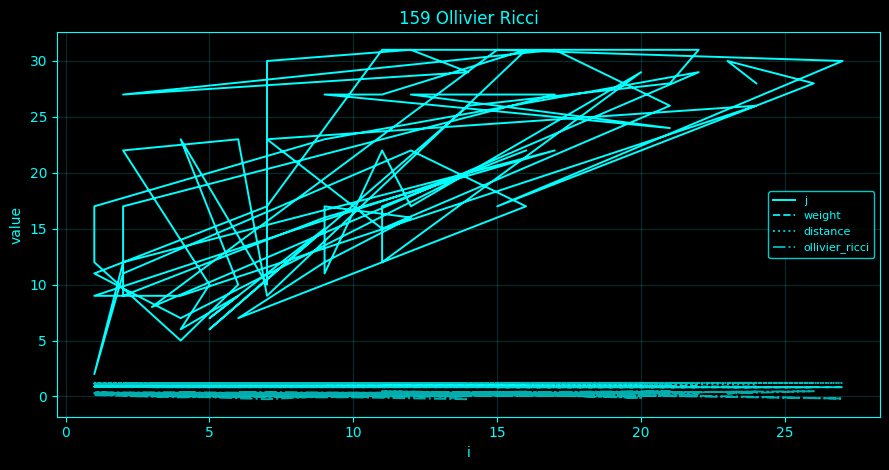

,i,j,weight,distance,ollivier_ricci,channel_i,channel_j
0,16,22,0.988999,1.011122,0.307151,C4,CP6
1,11,17,0.976188,1.024392,0.464580,FC6,T8
2,11,16,0.976185,1.024395,0.283593,FC6,C4
3,11,12,0.969705,1.031241,0.477454,FC6,M1
4,20,29,0.967428,1.033667,-0.127926,CP1,O1
...,...,...,...,...,...,...,...
65,27,30,0.829405,1.205682,-0.190308,P8,Oz
66,15,17,0.826590,1.209788,0.250025,Cz,T8
67,26,28,0.826509,1.209907,0.470018,P4,POz
68,23,30,0.826348,1.210143,0.263161,P7,Oz


In [164]:
grsave('159_ollivier_ricci',OR0.assign(channel_i=[eeg_channel_names[i] for i in OR0.i],channel_j=[eeg_channel_names[j] for j in OR0.j]))

### Forman-Ricci curvature

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Forman-Ricci curvature</h3><p>For an unweighted simple graph with unit vertex and edge weights, Forman edge curvature reduces to 4-deg(u)-deg(v). The cell deliberately uses this canonical unweighted specialization rather than mixing it with weighted formulas.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$F(e)=4-\deg(u)-\deg(v).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 i  j  forman_ricci channel_i channel_j
 0  3            -8       Fp1        F7
 0  5            -7       Fp1        Fz
 0  6           -11       Fp1        F4
 0  8            -7       Fp1       FC5
 0 10            -9       Fp1       FC2
 1  2            -9       Fpz       Fp2
 1  9           -15       Fpz       FC1
 1 11           -12       Fpz       FC6
 1 12           -11       Fpz        M1
 1 17           -13       Fpz        T8
 2  9           -18       Fp2       FC1
 2 11           -15       Fp2       FC6


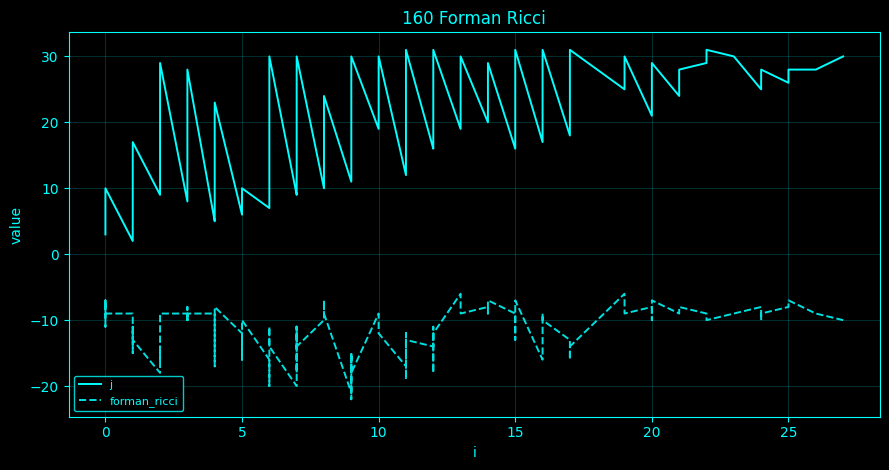

,i,j,forman_ricci,channel_i,channel_j
0,0,3,-8,Fp1,F7
1,0,5,-7,Fp1,Fz
2,0,6,-11,Fp1,F4
3,0,8,-7,Fp1,FC5
4,0,10,-9,Fp1,FC2
...,...,...,...,...,...
109,24,28,-9,P3,POz
110,25,26,-8,Pz,P4
111,25,28,-7,Pz,POz
112,26,28,-9,P4,POz


In [165]:
grsave('160_forman_ricci',FR0.assign(channel_i=[eeg_channel_names[i] for i in FR0.i],channel_j=[eeg_channel_names[j] for j in FR0.j]))

### Bakry-Émery curvature

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Bakry-Émery curvature</h3><p>For the continuous-time random-walk generator L=P-I, the curvature-dimension condition CD(K,infinity) requires Gamma2(f)>=K Gamma(f) at a vertex. The optimal local K is obtained from the smallest generalized eigenvalue of the two quadratic forms.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$\Gamma_2(f)(x)\ge K_x\Gamma(f)(x).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


channel  CD_K_infinity_lower_bound
    Fp1                   0.765177
     F7                   0.556572
     F4                   0.738520
    FC5                   0.746797
    FC6                   0.695798
     C3                   0.801179
     T8                   0.605384
    CP1                   0.673003
     P7                   1.137337
     Pz                   0.758536
    POz                   0.927040
     O2                   1.066926


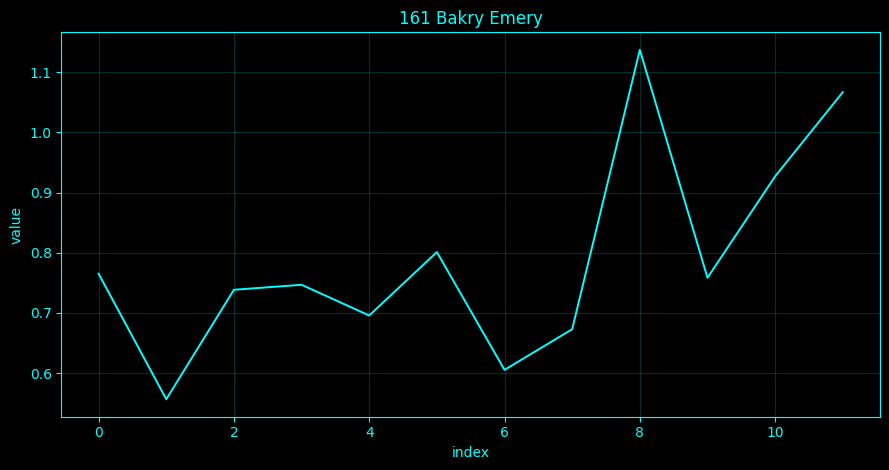

,channel,CD_K_infinity_lower_bound
0,Fp1,0.765177
1,F7,0.556572
2,F4,0.738520
3,FC5,0.746797
4,FC6,0.695798
5,C3,0.801179
6,T8,0.605384
7,CP1,0.673003
8,P7,1.137337
9,Pz,0.758536


In [166]:
ids=np.arange(nC) if FAST_OPTION!='ultra' else np.unique(np.linspace(0,nC-1,12).round().astype(int));rows=[(eeg_channel_names[i],bakry_node(W0,int(i))) for i in ids];grsave('161_bakry_emery',pd.DataFrame(rows,columns=['channel','CD_K_infinity_lower_bound']))

### Menger curvature

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Menger curvature</h3><p>Menger curvature of three noncollinear points is the reciprocal circumradius. It converges to ordinary curve curvature for suitably shrinking triples on a smooth curve.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$\kappa_M(a,b,c)=4\,Area(a,b,c)/(\|a-b\|\|b-c\|\|c-a\|).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 time_sec  menger_curvature
  818.071          0.315105
  820.571          0.372376
  823.071          0.640167
  825.571          3.788498
  828.071          1.182549
  830.571          1.394154
  833.071          0.410970
  835.571          0.393644
  838.071          0.449993
  840.571          1.543520
  843.071          1.105545
  845.571          1.111943


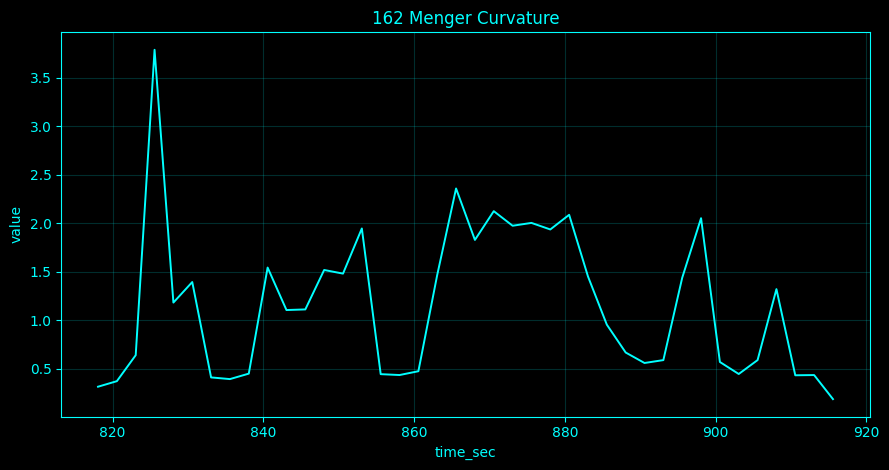

,time_sec,menger_curvature
0,818.071,0.315105
1,820.571,0.372376
2,823.071,0.640167
3,825.571,3.788498
4,828.071,1.182549
5,830.571,1.394154
6,833.071,0.410970
7,835.571,0.393644
8,838.071,0.449993
9,840.571,1.543520


In [167]:
vals=[]
for i in range(1,len(R)-1):vals.append((RT[i],menger(R[i-1],R[i],R[i+1])))
grsave('162_menger_curvature',pd.DataFrame(vals,columns=['time_sec','menger_curvature']))

### Haantjes curvature

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Haantjes curvature</h3><p>For a short polygonal arc with path length l and endpoint chord d, Haantjes curvature is estimated by sqrt(24(l-d)/d^3). This is a discrete curve curvature based on excess path length.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$\kappa_H=\sqrt{24(\ell-d)/d^3}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 time_sec  haantjes_curvature
  818.071            4.328051
  820.571            0.434317
  823.071            1.343433
  825.571           30.200660
  828.071            4.030050
  830.571            5.104803
  833.071            0.448067
  835.571            8.232802
  838.071            0.443034
  840.571            4.626600
  843.071           24.941473
  845.571            1.860712


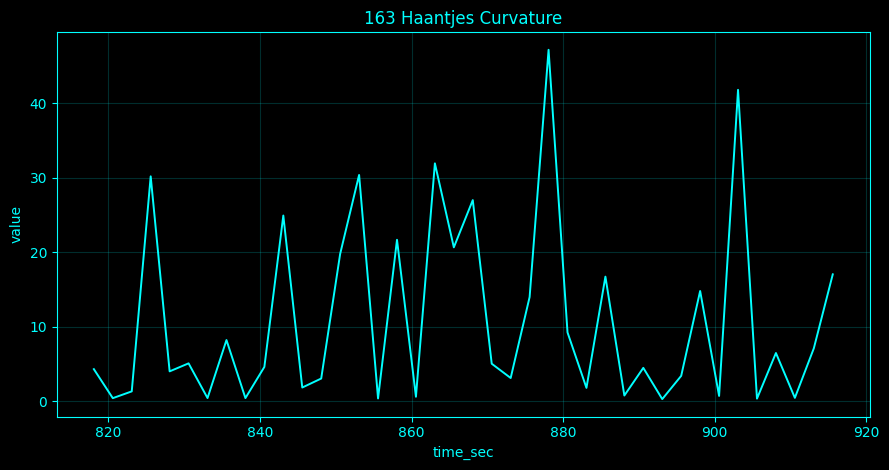

,time_sec,haantjes_curvature
0,818.071,4.328051
1,820.571,0.434317
2,823.071,1.343433
3,825.571,30.200660
4,828.071,4.030050
5,830.571,5.104803
6,833.071,0.448067
7,835.571,8.232802
8,838.071,0.443034
9,840.571,4.626600


In [168]:
vals=[]
for i in range(1,len(R)-1):vals.append((RT[i],haantjes(R[i-1],R[i],R[i+1])))
grsave('163_haantjes_curvature',pd.DataFrame(vals,columns=['time_sec','haantjes_curvature']))

### Graph sectional curvature

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Graph sectional curvature</h3><p>There is no unique canonical graph analogue of Riemannian sectional curvature. This cell therefore labels lazy Ollivier edge curvature as an edge-sectional proxy and does not present it as a theorem-level sectional curvature.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$K_e^{proxy}:=\kappa_{OR}(e).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 i  j  edge_sectional_proxy
16 22              0.307151
11 17              0.464580
11 16              0.283593
11 12              0.477454
20 29             -0.127926
12 17              0.421293
11 22              0.118669
 9 11              0.087536
 9 17              0.142613
12 16              0.242537
 9 12              0.095739
 6  7              0.400566


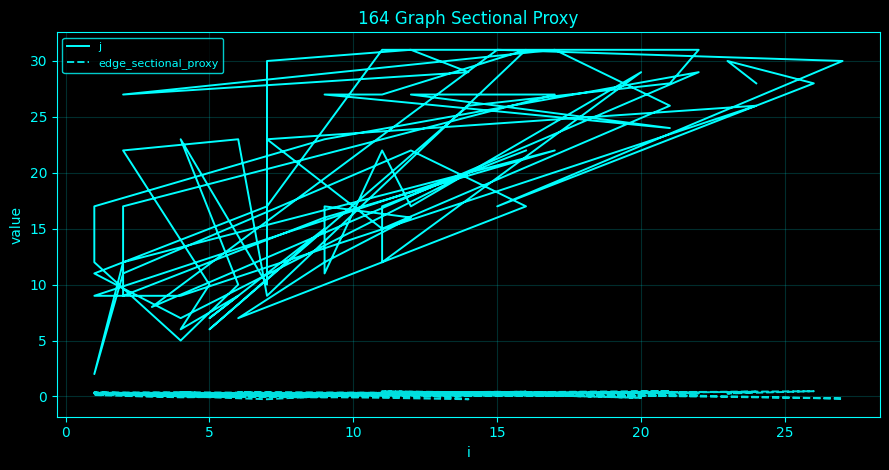

,i,j,edge_sectional_proxy
0,16,22,0.307151
1,11,17,0.464580
2,11,16,0.283593
3,11,12,0.477454
4,20,29,-0.127926
...,...,...,...
65,27,30,-0.190308
66,15,17,0.250025
67,26,28,0.470018
68,23,30,0.263161


In [169]:
grsave('164_graph_sectional_proxy',OR0[['i','j','ollivier_ricci']].rename(columns={'ollivier_ricci':'edge_sectional_proxy'}))

### Graph scalar curvature

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Graph scalar curvature</h3><p>A commonly used graph scalar-curvature summary is the sum of incident edge Ricci curvatures. This is a discrete convention, not the unique continuum scalar curvature.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$S_i^{proxy}=\sum_{j\sim i}\kappa_{OR}(i,j).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


channel  incident_ollivier_sum
    Fp1               0.000000
    Fpz               1.362110
    Fp2               1.792604
     F7               0.069416
     F3               1.356278
     Fz               1.075110
     F4               1.460754
     F8               1.392879
    FC5               0.069416
    FC1               0.554513
    FC2               0.552341
    FC6               2.787459


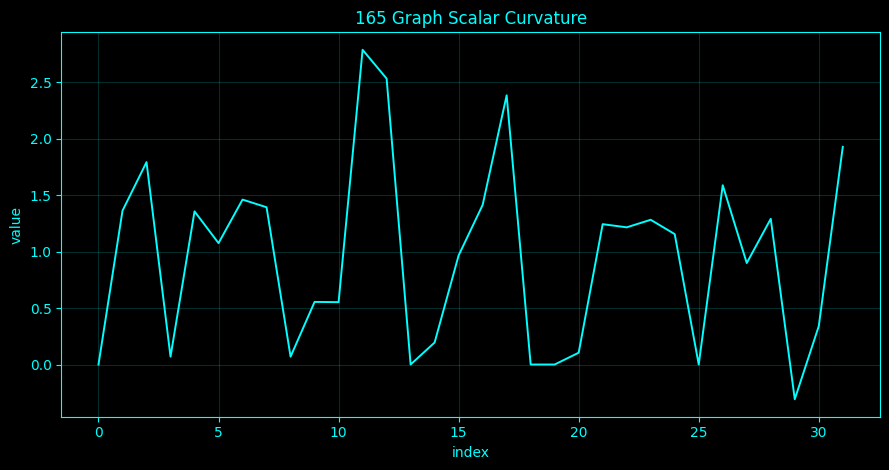

,channel,incident_ollivier_sum
0,Fp1,0.000000
1,Fpz,1.362110
2,Fp2,1.792604
3,F7,0.069416
4,F3,1.356278
5,Fz,1.075110
6,F4,1.460754
7,F8,1.392879
8,FC5,0.069416
9,FC1,0.554513


In [170]:
sv=np.zeros(nC)
for r in OR0.itertuples():sv[r.i]+=r.ollivier_ricci;sv[r.j]+=r.ollivier_ricci
grsave('165_graph_scalar_curvature',pd.DataFrame({'channel':eeg_channel_names,'incident_ollivier_sum':sv}))

### Curvature of functional connectivity networks

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Curvature of functional connectivity networks</h3><p>The absolute-correlation kNN network is the baseline functional-connectivity graph. Its curvature distribution is summarized with lazy Ollivier curvature on evaluated edges.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$W_{ij}=|corr(x_i,x_j)|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 mean_OR  median_OR  fraction_negative
0.219292   0.263255                0.1


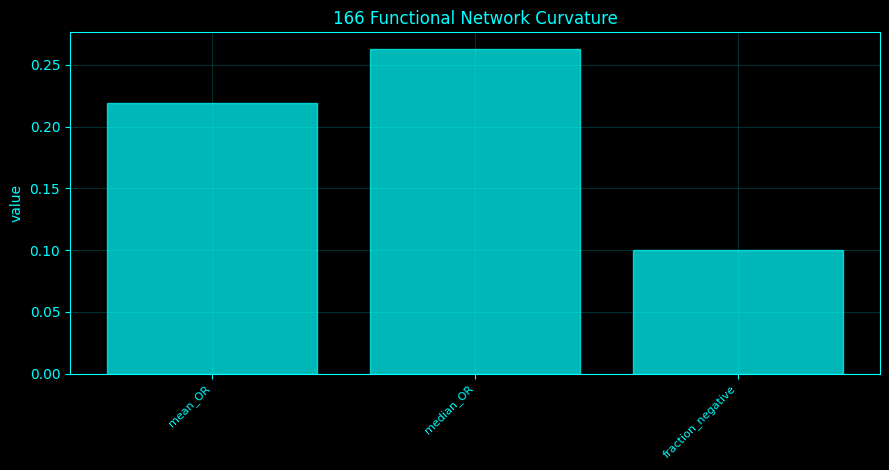

,mean_OR,median_OR,fraction_negative
0,0.219292,0.263255,0.1


In [171]:
grsave('166_functional_network_curvature',pd.DataFrame({'mean_OR':[OR0.ollivier_ricci.mean()],'median_OR':[OR0.ollivier_ricci.median()],'fraction_negative':[(OR0.ollivier_ricci<0).mean()]}))

### Curvature of coherence networks

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Curvature of coherence networks</h3><p>Magnitude-squared coherence averaged over 8–30 Hz defines a second weighted graph; the same Ollivier construction is then applied so only the graph definition changes.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$C_{xy}(f)=|S_{xy}(f)|^2/(S_{xx}(f)S_{yy}(f)).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 i  j   weight  distance  ollivier_ricci
29 30 0.875335  1.142419        0.489655
30 31 0.783380  1.276518        0.248900
 1  2 0.782250  1.278363        0.230740
25 28 0.774636  1.290927        0.031166
 6 10 0.772687  1.294184        0.066448
11 16 0.753447  1.327232        0.176538
 5  9 0.749174  1.334801        0.036293
 5 10 0.735733  1.359186        0.059885
 7 11 0.731836  1.366424        0.072843
 5  6 0.713239  1.402053       -0.033474
28 30 0.701857  1.424791        0.201653
 4  9 0.681417  1.467528        0.054629


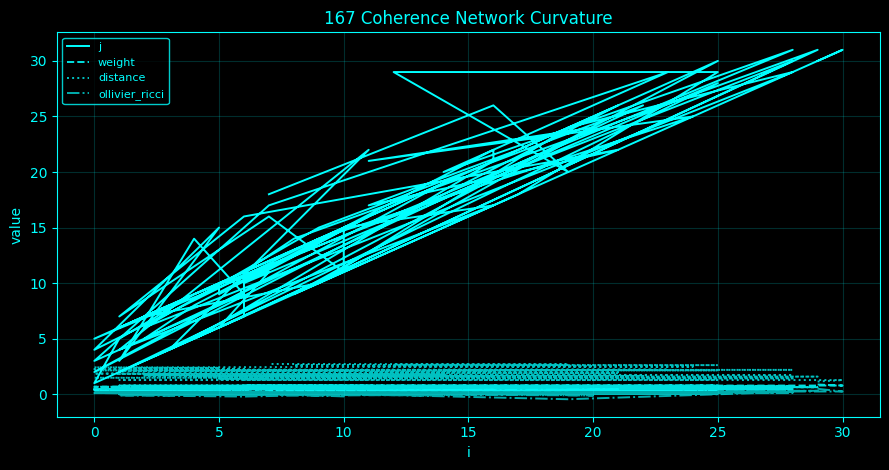

,i,j,weight,distance,ollivier_ricci
0,29,30,0.875335,1.142419,0.489655
1,30,31,0.783380,1.276518,0.248900
2,1,2,0.782250,1.278363,0.230740
3,25,28,0.774636,1.290927,0.031166
4,6,10,0.772687,1.294184,0.066448
...,...,...,...,...,...
65,25,29,0.381770,2.619370,0.107379
66,12,29,0.375823,2.660817,0.107581
67,19,20,0.372019,2.688028,0.340989
68,16,26,0.370141,2.701664,0.225467


In [172]:
orc=ollivier_edges(WCOH,.5,GR_CFG['or_edges']);grsave('167_coherence_network_curvature',orc)

### Curvature of PLV networks

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Curvature of PLV networks</h3><p>Phase-locking value is the magnitude of the mean unit phase-difference vector. A kNN PLV graph is curved with the same transport definition.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$PLV_{ij}=|N^{-1}\sum_t e^{i(\phi_i-\phi_j)}|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Phase-locking value measures how consistent the phase difference between two signals is across samples, trials, or windows. Each phase difference is converted to a unit complex number on the circle and these vectors are averaged. If phase differences are almost identical, the vectors point in the same direction and the average magnitude approaches one. If phase differences are widely spread, they cancel and the magnitude approaches zero. PLV ignores amplitude and does not establish causal influence.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 i  j   weight  distance  ollivier_ricci
16 22 0.989596  1.010512        0.302216
11 17 0.956151  1.045859        0.479577
11 16 0.948204  1.054625        0.191815
11 22 0.943684  1.059675        0.032942
20 29 0.939966  1.063867        0.222590
11 12 0.939170  1.064769        0.375736
12 16 0.932326  1.072585        0.281643
 2 16 0.929282  1.076099        0.365413
12 22 0.929194  1.076200        0.108589
12 17 0.924112  1.082118        0.424661
 2 22 0.919365  1.087706        0.243000
 2 11 0.912896  1.095413        0.160855


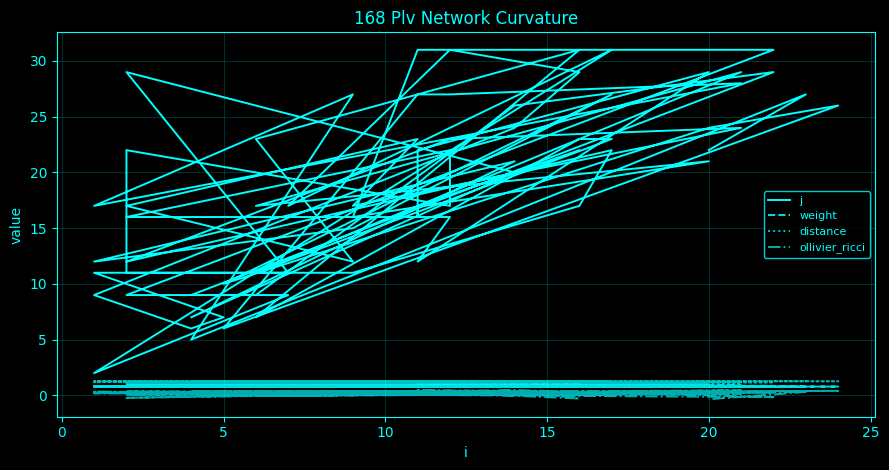

,i,j,weight,distance,ollivier_ricci
0,16,22,0.989596,1.010512,0.302216
1,11,17,0.956151,1.045859,0.479577
2,11,16,0.948204,1.054625,0.191815
3,11,22,0.943684,1.059675,0.032942
4,20,29,0.939966,1.063867,0.222590
...,...,...,...,...,...
65,1,17,0.786274,1.271819,0.258552
66,9,27,0.782175,1.278485,0.201217
67,4,5,0.781466,1.279645,0.195686
68,23,27,0.781385,1.279778,0.306759


In [173]:
orp=ollivier_edges(WPLV,.5,GR_CFG['or_edges']);grsave('168_plv_network_curvature',orp)

### Curvature of transfer-entropy networks

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Curvature of transfer-entropy networks</h3><p>Linear-Gaussian lag-one transfer entropy is directed. To apply undirected Ollivier curvature, the directed TE strengths are symmetrized only for this curvature cell; the original directed TE matrix is retained separately.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$TE_{X\to Y}=\tfrac12\log(\sigma^2_{Y|Y^-}/\sigma^2_{Y|Y^-,X^-}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Transfer entropy measures whether the past of one signal provides information about the future of another beyond the information already contained in the target signal's own past. Mathematically it is a conditional information measure, so direction matters: transfer from X to Y is not generally equal to transfer from Y to X. In finite EEG recordings, reliable estimation can require many samples because the method estimates conditional probability structure in a multidimensional history space.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 i  j   weight  distance  ollivier_ricci
17 27 0.176834  5.654990       -0.113276
 9 27 0.136060  7.349622       -0.457903
12 27 0.133038  7.516569       -0.013910
11 27 0.131297  7.616257       -0.108830
 4 23 0.090595 11.038058        0.211769
 7 13 0.089949 11.117255       -0.007511
 3 21 0.088237 11.332970        0.096557
13 30 0.086806 11.519858       -0.018608
 6 23 0.086443 11.568204        0.213395
 6 13 0.086192 11.601873       -0.076131
22 27 0.086057 11.620057       -0.215706
12 17 0.085375 11.712846        0.262983


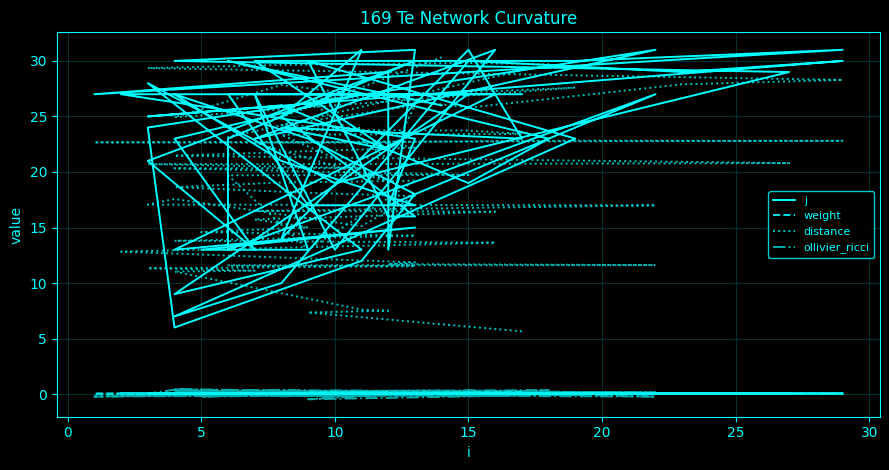

,i,j,weight,distance,ollivier_ricci
0,17,27,0.176834,5.654990,-0.113276
1,9,27,0.136060,7.349622,-0.457903
2,12,27,0.133038,7.516569,-0.013910
3,11,27,0.131297,7.616257,-0.108830
4,4,23,0.090595,11.038058,0.211769
...,...,...,...,...,...
65,8,26,0.033737,29.640599,0.173395
66,15,19,0.033540,29.814492,0.097816
67,18,23,0.033477,29.688868,0.362105
68,6,30,0.033465,23.121731,0.236943


In [174]:
WTE=graph_from_similarity(TE+TE.T);ort=ollivier_edges(WTE,.5,GR_CFG['or_edges']);grsave('169_te_network_curvature',ort)

### Curvature flow on EEG graphs

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Curvature flow on EEG graphs</h3><p>A simple curvature flow updates positive edge lengths in the direction d ell/dt = -kappa ell, followed by rescaling to preserve mean length. This is an algorithmic discrete Ricci-flow analogue, not a continuum PDE identity.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$\dot\ell_e=-\kappa_e\ell_e.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 iteration  mean_OR  edge_length_std
         0 0.219292         0.143468
         1 0.223198         0.153759
         2 0.231242         0.164732
         3 0.230450         0.176251
         4 0.229444         0.188171
         5 0.229478         0.200334
         6 0.235894         0.212538
         7 0.235152         0.224870
         8 0.234381         0.237270
         9 0.233574         0.249692
        10 0.232735         0.262099
        11 0.231906         0.274462


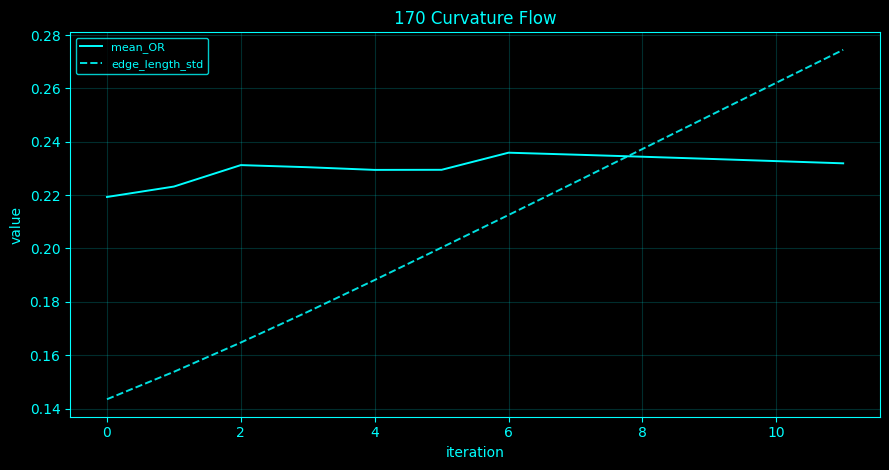

,iteration,mean_OR,edge_length_std
0,0,0.219292,0.143468
1,1,0.223198,0.153759
2,2,0.231242,0.164732
3,3,0.230450,0.176251
4,4,0.229444,0.188171
5,5,0.229478,0.200334
6,6,0.235894,0.212538
7,7,0.235152,0.224870
8,8,0.234381,0.237270
9,9,0.233574,0.249692


In [175]:
Lf=lengths(W0);mask=np.isfinite(Lf)&(Lf>0);hist=[]
for it in range(GR_CFG['flow']):
 W=np.zeros_like(W0);W[mask]=1/(Lf[mask]+EPS);orc=ollivier_edges(W,.5,min(GR_CFG['or_edges'],len(edge_list(W))));
 for r in orc.itertuples():Lf[r.i,r.j]=Lf[r.j,r.i]=max(1e-5,Lf[r.i,r.j]*(1-.08*r.ollivier_ricci))
 Lf[mask]*=np.mean(lengths(W0)[mask])/(np.mean(Lf[mask])+EPS);hist.append((it,float(np.mean(orc.ollivier_ricci)),float(np.std(Lf[mask]))))
grsave('170_curvature_flow',pd.DataFrame(hist,columns=['iteration','mean_OR','edge_length_std']))

### Ricci flow on EEG graphs

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Ricci flow on EEG graphs</h3><p>The same length evolution is interpreted as a discrete Ricci-flow experiment because its driving curvature is Ollivier–Ricci. Mean-length renormalization prevents trivial global collapse or expansion.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$\ell_e^{n+1}\propto\ell_e^n(1-\eta\kappa_e^n).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The proportionality symbol means the two quantities are expected to follow the same scaling law up to a multiplicative constant.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 iteration  mean_OR  edge_length_std
         0 0.219292         0.143468
         1 0.223198         0.153759
         2 0.231242         0.164732
         3 0.230450         0.176251
         4 0.229444         0.188171
         5 0.229478         0.200334
         6 0.235894         0.212538
         7 0.235152         0.224870
         8 0.234381         0.237270
         9 0.233574         0.249692
        10 0.232735         0.262099
        11 0.231906         0.274462


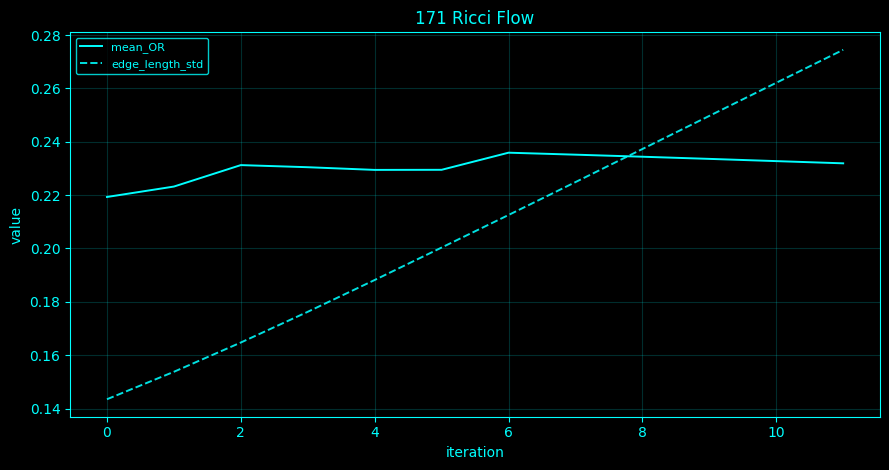

,iteration,mean_OR,edge_length_std
0,0,0.219292,0.143468
1,1,0.223198,0.153759
2,2,0.231242,0.164732
3,3,0.230450,0.176251
4,4,0.229444,0.188171
5,5,0.229478,0.200334
6,6,0.235894,0.212538
7,7,0.235152,0.224870
8,8,0.234381,0.237270
9,9,0.233574,0.249692


In [176]:
grsave('171_ricci_flow',pd.DataFrame(hist,columns=['iteration','mean_OR','edge_length_std']))

### Discrete mean-curvature flow

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Discrete mean-curvature flow</h3><p>For a scalar feature f on graph vertices, graph-Laplacian heat flow df/dt=-Lf is the gradient flow of Dirichlet energy f^T L f/2. The cell tracks that guaranteed dissipating energy rather than assuming Euclidean spatial radius must decrease.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$\dot f=-Lf,\qquad E(f)=\tfrac12 f^TLf,\quad dE/dt=-\|Lf\|^2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 iteration  dirichlet_energy  feature_variance
         0          0.876144          0.012470
         1          0.573422          0.009192
         2          0.388102          0.007029
         3          0.270326          0.005555
         4          0.193206          0.004522
         5          0.141446          0.003780
         6          0.105959          0.003234
         7          0.081158          0.002822
         8          0.063511          0.002506
         9          0.050739          0.002257
        10          0.041340          0.002057
        11          0.034312          0.001893


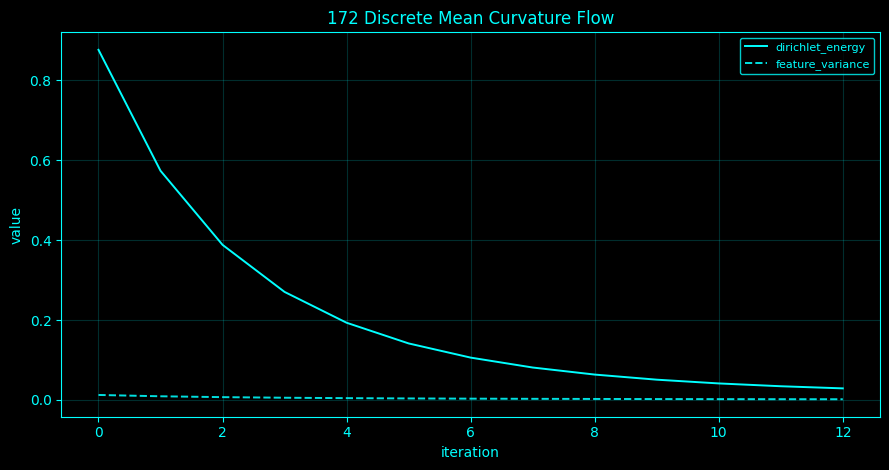

,iteration,dirichlet_energy,feature_variance
0,0,0.876144,0.012470
1,1,0.573422,0.009192
2,2,0.388102,0.007029
3,3,0.270326,0.005555
4,4,0.193206,0.004522
5,5,0.141446,0.003780
6,6,0.105959,0.003234
7,7,0.081158,0.002822
8,8,0.063511,0.002506
9,9,0.050739,0.002257


In [177]:
Dg=np.diag(W0.sum(1));L=Dg-W0;lam=np.linalg.eigvalsh(L).max();eta=.45/(lam+EPS);f0=BP_PROB[2].copy();f=f0.copy();rows=[]
for it in range(GR_CFG['flow']+1):rows.append((it,.5*float(f@L@f),float(np.var(f))));f=f-eta*(L@f)
grsave('172_discrete_mean_curvature_flow',pd.DataFrame(rows,columns=['iteration','dirichlet_energy','feature_variance']))

### Graph curvature community detection

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Graph curvature community detection</h3><p>Curvature-adjusted edge similarity multiplies functional weight by exp(kappa), then average-linkage clustering groups vertices from the resulting shortest-path distance. This is a curvature-aware clustering heuristic, not a unique Ricci-community theorem.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$w_{ij}^{curv}=w_{ij}e^{\kappa_{ij}}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


channel  community
    Fp1          1
    Fpz          4
    Fp2          4
     F7          1
     F3          3
     Fz          3
     F4          3
     F8          3
    FC5          1
    FC1          4
    FC2          3
    FC6          4


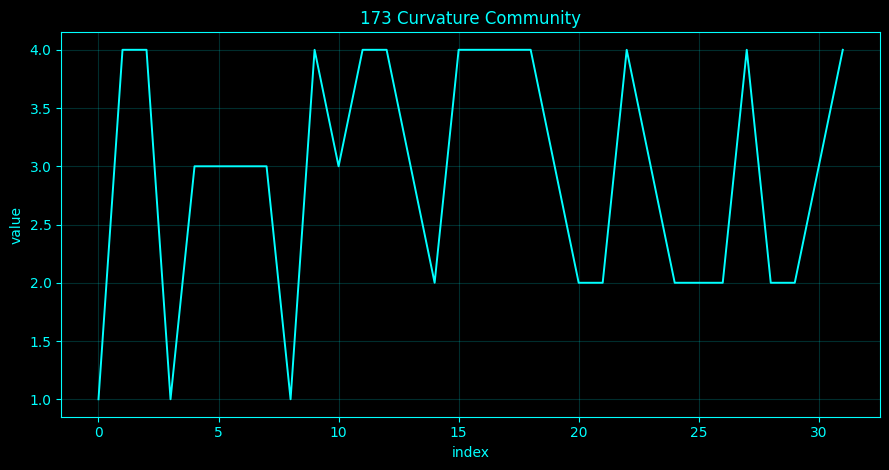

,channel,community
0,Fp1,1
1,Fpz,4
2,Fp2,4
3,F7,1
4,F3,3
5,Fz,3
6,F4,3
7,F8,3
8,FC5,1
9,FC1,4


In [178]:
WC=W0.copy()
for r in OR0.itertuples():WC[r.i,r.j]=WC[r.j,r.i]=W0[r.i,r.j]*np.exp(r.ollivier_ricci)
DC=graph_dist(WC);lab=fcluster(linkage(_sqf(DC,checks=False),method='average'),4,criterion='maxclust');grsave('173_curvature_community',pd.DataFrame({'channel':eeg_channel_names,'community':lab}))

### Curvature-weighted hub detection

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Curvature-weighted hub detection</h3><p>A curvature-weighted hub score sums incident conductance multiplied by one plus positive Ollivier curvature. It is explicitly a constructed hub feature, while ordinary weighted degree is reported alongside it.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$h_i=\sum_jw_{ij}(1+\max(\kappa_{ij},0)).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


channel  weighted_degree  curvature_weighted_hub_score
    Fp1         3.153139                      3.153139
    Fpz         4.349924                      5.538817
    Fp2         7.173826                      8.807449
     F7         5.246721                      5.304444
     F3         5.892967                      7.133908
     Fz         4.953543                      5.891962
     F4         8.302204                      9.688199
     F8         8.570750                     10.021370
    FC5         4.305182                      4.362905
    FC1        12.413210                     13.148363
    FC2         6.231470                      6.710212
    FC6        10.072142                     12.671268


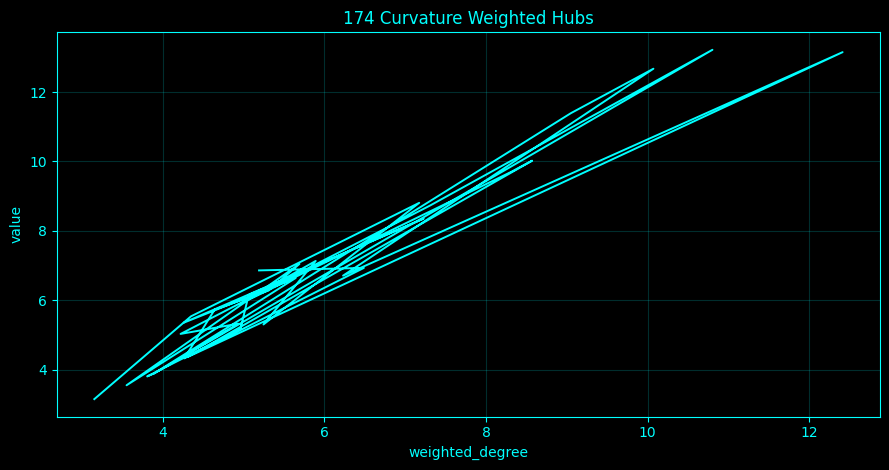

,channel,weighted_degree,curvature_weighted_hub_score
0,Fp1,3.153139,3.153139
1,Fpz,4.349924,5.538817
2,Fp2,7.173826,8.807449
3,F7,5.246721,5.304444
4,F3,5.892967,7.133908
5,Fz,4.953543,5.891962
6,F4,8.302204,9.688199
7,F8,8.570750,10.021370
8,FC5,4.305182,4.362905
9,FC1,12.413210,13.148363


In [179]:
hub=W0.sum(1).copy()
for r in OR0.itertuples():hub[r.i]+=W0[r.i,r.j]*max(r.ollivier_ricci,0);hub[r.j]+=W0[r.i,r.j]*max(r.ollivier_ricci,0)
grsave('174_curvature_weighted_hubs',pd.DataFrame({'channel':eeg_channel_names,'weighted_degree':W0.sum(1),'curvature_weighted_hub_score':hub}))

### Curvature bottleneck detection

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Curvature bottleneck detection</h3><p>Strongly negative Ollivier curvature indicates neighborhood expansion across an edge and is often used as a bottleneck signal. The cell ranks evaluated edges from most negative upward.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$b_e=-\kappa_{OR}(e).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 i  j   weight  distance  ollivier_ricci channel_i channel_j
14 29 0.849569  1.177066       -0.251522        C3        O1
 7 17 0.877695  1.139347       -0.250557        F8        T8
27 30 0.829405  1.205682       -0.190308        P8        Oz
20 29 0.967428  1.033667       -0.127926       CP1        O1
 9 16 0.918637  1.088568       -0.087660       FC1        C4
 6  9 0.884334  1.130794       -0.084586        F4       FC1
 4  9 0.869725  1.149787       -0.080299        F3       FC1
 7  9 0.898121  1.113434        0.012395        F8       FC1
 9 15 0.883828  1.131440        0.023122       FC1        Cz
 2  9 0.918516  1.088712        0.036798       Fp2       FC1
 3  8 0.831546  1.202577        0.069416        F7       FC5
22 29 0.831690  1.202369        0.071703       CP6        O1


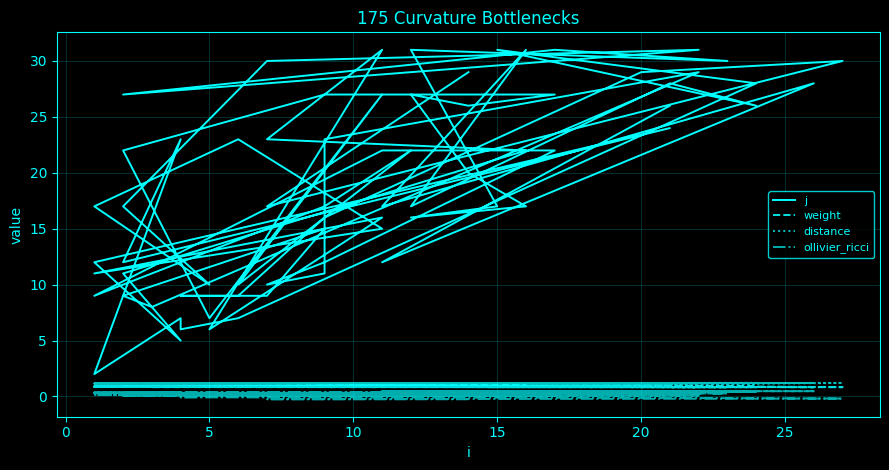

,i,j,weight,distance,ollivier_ricci,channel_i,channel_j
52,14,29,0.849569,1.177066,-0.251522,C3,O1
40,7,17,0.877695,1.139347,-0.250557,F8,T8
65,27,30,0.829405,1.205682,-0.190308,P8,Oz
4,20,29,0.967428,1.033667,-0.127926,CP1,O1
18,9,16,0.918637,1.088568,-0.087660,FC1,C4
...,...,...,...,...,...,...,...
26,16,31,0.900532,1.110454,0.426982,C4,O2
1,11,17,0.976188,1.024392,0.464580,FC6,T8
67,26,28,0.826509,1.209907,0.470018,P4,POz
3,11,12,0.969705,1.031241,0.477454,FC6,M1


In [180]:
q=OR0.sort_values('ollivier_ricci').copy();q['channel_i']=[eeg_channel_names[i] for i in q.i];q['channel_j']=[eeg_channel_names[j] for j in q.j];grsave('175_curvature_bottlenecks',q)

### Curvature-based edge vulnerability

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Curvature-based edge vulnerability</h3><p>Edge vulnerability is measured operationally as the change in graph algebraic connectivity after deleting one edge. Curvature is then compared with that deletion impact rather than assumed to equal vulnerability.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$v_e=\lambda_2(L)-\lambda_2(L_{-e}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 i  j  OR_curvature  algebraic_connectivity_drop
16 22      0.307151                     0.002044
11 17      0.464580                     0.000007
11 16      0.283593                     0.000425
11 12      0.477454                     0.000001
20 29     -0.127926                     0.044964
12 17      0.421293                     0.000002
11 22      0.118669                     0.004146
 9 11      0.087536                     0.000202
 9 17      0.142613                     0.000129
12 16      0.242537                     0.000371
 9 12      0.095739                     0.000169
 6  7      0.400566                     0.000265


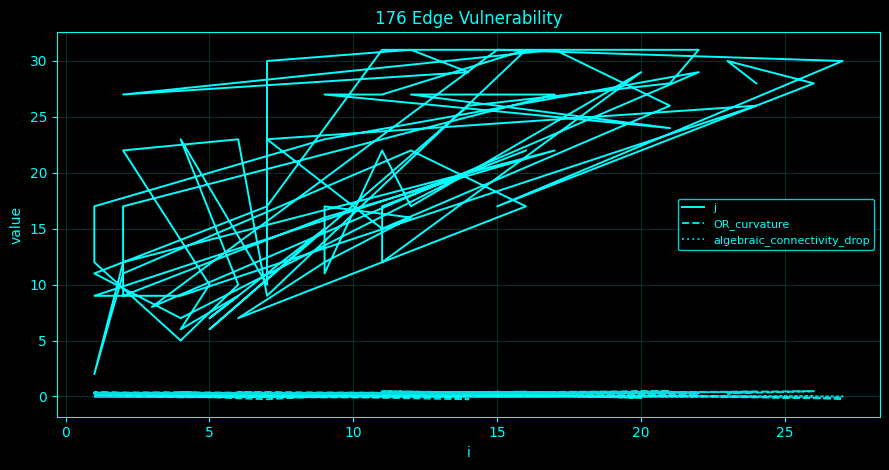

,i,j,OR_curvature,algebraic_connectivity_drop
0,16,22,0.307151,0.002044
1,11,17,0.464580,0.000007
2,11,16,0.283593,0.000425
3,11,12,0.477454,0.000001
4,20,29,-0.127926,0.044964
...,...,...,...,...
65,27,30,-0.190308,0.003790
66,15,17,0.250025,0.000311
67,26,28,0.470018,0.000202
68,23,30,0.263161,0.001099


In [181]:
def algconn(W):L=np.diag(W.sum(1))-W;z=np.linalg.eigvalsh((L+L.T)/2);return float(z[1]) if len(z)>1 else 0
baseac=algconn(W0);rows=[]
for r in OR0.itertuples():
 W=W0.copy();W[r.i,r.j]=W[r.j,r.i]=0;rows.append((r.i,r.j,r.ollivier_ricci,baseac-algconn(W)))
grsave('176_edge_vulnerability',pd.DataFrame(rows,columns=['i','j','OR_curvature','algebraic_connectivity_drop']))

### Curvature-based network robustness

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Curvature-based network robustness</h3><p>Edges are removed from most negative curvature upward and the largest connected-component fraction is tracked. This is a targeted robustness curve, contrasted with the intact graph at removal fraction zero.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$R(q)=|C_{max}(G_q)|/|V|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 fraction_ranked_edges_removed  largest_component_fraction
                      0.000000                     1.00000
                      0.014286                     1.00000
                      0.128571                     1.00000
                      0.228571                     1.00000
                      0.342857                     1.00000
                      0.457143                     1.00000
                      0.557143                     0.96875
                      0.671429                     0.96875
                      0.785714                     0.78125
                      0.885714                     0.75000
                      1.000000                     0.75000


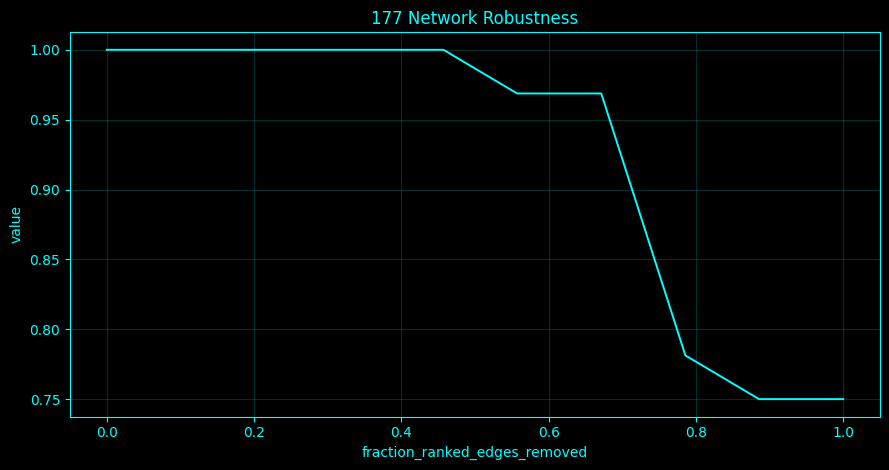

,fraction_ranked_edges_removed,largest_component_fraction
0,0.000000,1.00000
1,0.014286,1.00000
2,0.128571,1.00000
3,0.228571,1.00000
4,0.342857,1.00000
5,0.457143,1.00000
6,0.557143,0.96875
7,0.671429,0.96875
8,0.785714,0.78125
9,0.885714,0.75000


In [182]:
def largest_comp_frac(W):
 A=W>0;n=len(W);seen=set();best=0
 for s in range(n):
  if s in seen:continue
  stack=[s];seen.add(s);m=0
  while stack:
   u=stack.pop();m+=1
   for v in np.where(A[u])[0]:
    if int(v) not in seen:seen.add(int(v));stack.append(int(v))
  best=max(best,m)
 return best/n
ordE=[(int(r.i),int(r.j)) for r in OR0.sort_values('ollivier_ricci').itertuples()];W=W0.copy();rows=[(0,largest_comp_frac(W))]
for k0,(i,j) in enumerate(ordE,1):
 W[i,j]=W[j,i]=0
 if k0 in np.unique(np.linspace(1,len(ordE),10).round().astype(int)):rows.append((k0/len(ordE),largest_comp_frac(W)))
grsave('177_network_robustness',pd.DataFrame(rows,columns=['fraction_ranked_edges_removed','largest_component_fraction']))

### Curvature assortativity

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Curvature assortativity</h3><p>Node curvature is the mean incident Ollivier curvature. Curvature assortativity is Pearson correlation of node-curvature values across evaluated edges.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$r_\kappa=corr(\bar\kappa_i,\bar\kappa_j)_{(i,j)\in E}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [183]:
nc=np.zeros(nC);ct=np.zeros(nC)
for r in OR0.itertuples():nc[r.i]+=r.ollivier_ricci;nc[r.j]+=r.ollivier_ricci;ct[r.i]+=1;ct[r.j]+=1
nc/=np.maximum(ct,1);x=[];y=[]
for r in OR0.itertuples():x.append(nc[r.i]);y.append(nc[r.j])
ass=np.corrcoef(x,y)[0,1] if np.std(x)>0 and np.std(y)>0 else np.nan;grsave('178_curvature_assortativity',pd.DataFrame({'curvature_assortativity':[ass]}))

 curvature_assortativity
                0.426103


,curvature_assortativity
0,0.426103


### Regional graph curvature summaries

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Regional graph curvature summaries</h3><p>Mean node curvature is summarized over predefined left, right and midline channel sets using the same node curvature convention.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$\bar\kappa_R=|R|^{-1}\sum_{i\in R}\bar\kappa_i.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 region  mean_node_curvature      std
   left             0.107203 0.137707
  right             0.234219 0.104209
midline             0.221033 0.135126


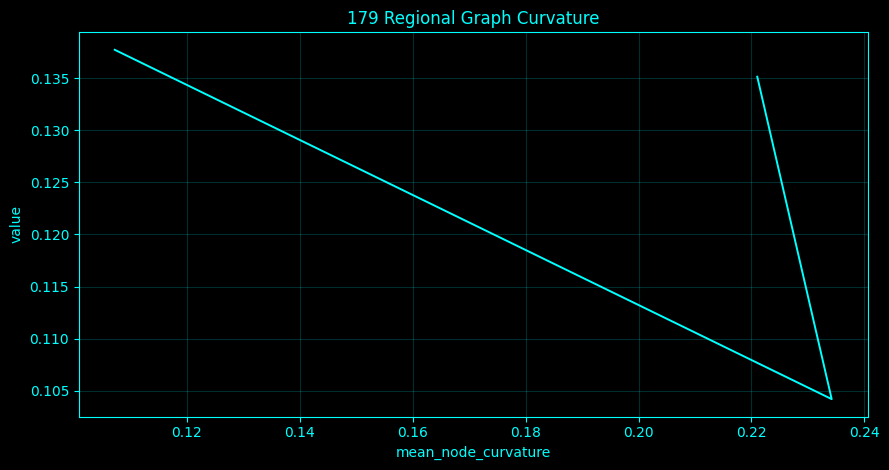

,region,mean_node_curvature,std
0,left,0.107203,0.137707
1,right,0.234219,0.104209
2,midline,0.221033,0.135126


In [184]:
REG={'left':LEFT,'right':RIGHT,'midline':MID};grsave('179_regional_graph_curvature',pd.DataFrame([(k,np.mean(nc[v]),np.std(nc[v])) for k,v in REG.items()],columns=['region','mean_node_curvature','std']))

### Band-specific graph curvature

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Band-specific graph curvature</h3><p>For each band, channel band power is converted to a similarity graph using inverse absolute log-power difference; Forman curvature is then summarized. This compares network geometry across spectral features without recomputing phase measures.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$w_{ij}^{(B)}=\exp(-|\log P_{Bi}-\log P_{Bj}|/s_B).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 band  mean_forman  std_forman
delta    -9.924528    2.295744
theta    -9.514563    2.248590
alpha    -8.597938    1.753923
 beta    -9.098039    1.485973
gamma    -9.060000    1.900664


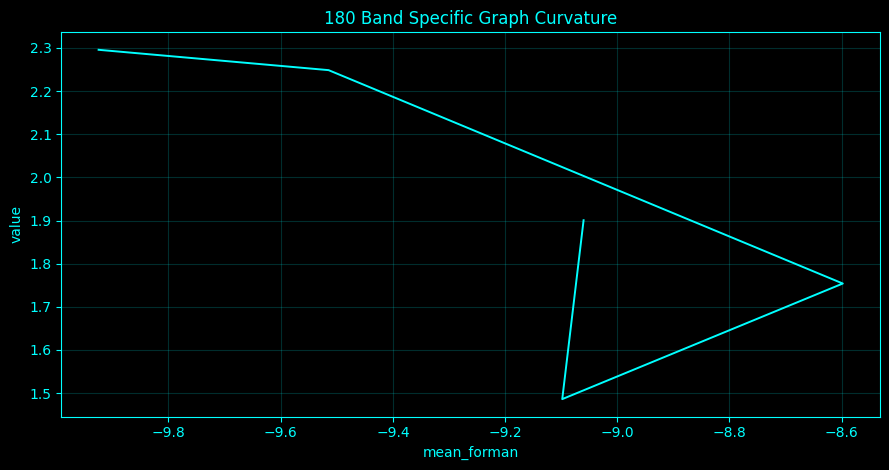

,band,mean_forman,std_forman
0,delta,-9.924528,2.295744
1,theta,-9.514563,2.248590
2,alpha,-8.597938,1.753923
3,beta,-9.098039,1.485973
4,gamma,-9.060000,1.900664


In [185]:
rows=[]
for bi,(bn,_,_) in enumerate(BANDS):
 x=np.log(BP[bi]+EPS);D=np.abs(x[:,None]-x[None,:]);sc=np.median(D[D>0])+EPS;W=graph_from_similarity(np.exp(-D/sc));F=forman_edges(W);rows.append((bn,F.forman_ricci.mean(),F.forman_ricci.std()))
grsave('180_band_specific_graph_curvature',pd.DataFrame(rows,columns=['band','mean_forman','std_forman']))

### Temporal graph curvature trajectories

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Temporal graph curvature trajectories</h3><p>Each EEG window yields an absolute-correlation kNN graph. Mean unweighted Forman curvature provides a fast, consistently defined temporal curvature trajectory across all speed modes.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$\bar F(t)=|E_t|^{-1}\sum_{e\in E_t}(4-d_u-d_v).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 time_sec  mean_forman_curvature  edges
  815.571             -11.689655    116
  820.571             -13.196721    122
  825.571             -10.892857    112
  830.571             -11.724138    116
  838.071             -11.178571    112
  843.071             -13.126050    119
  848.071             -11.543860    114
  853.071             -11.115044    113
  858.071             -11.535714    112
  863.071             -11.756522    115
  870.571             -11.614035    114
  875.571             -11.568966    116


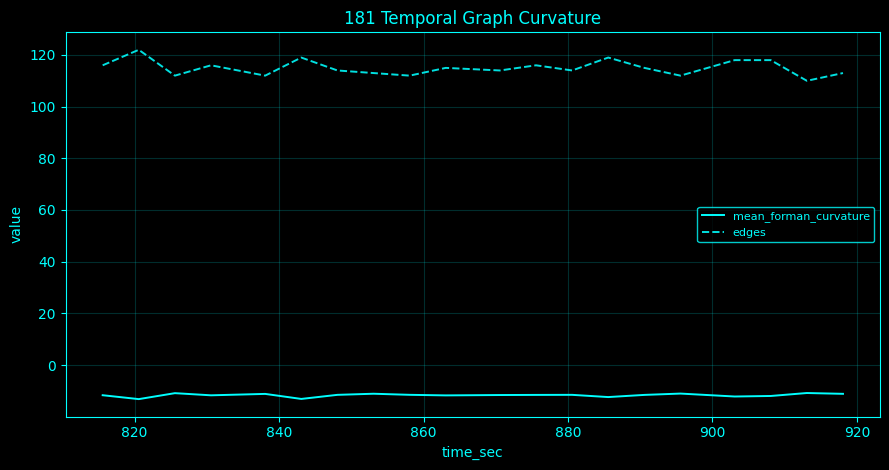

,time_sec,mean_forman_curvature,edges
0,815.571,-11.689655,116
1,820.571,-13.196721,122
2,825.571,-10.892857,112
3,830.571,-11.724138,116
4,838.071,-11.178571,112
5,843.071,-13.126050,119
6,848.071,-11.543860,114
7,853.071,-11.115044,113
8,858.071,-11.535714,112
9,863.071,-11.756522,115


In [186]:
wi=np.unique(np.linspace(0,N-1,min(N,GR_CFG['time'])).round().astype(int));rows=[]
for q in wi:
 a,b=BOUNDS[q];C=np.abs(np.corrcoef(EEG_STD[a:b],rowvar=False));W=graph_from_similarity(C);F=forman_edges(W);rows.append((STATE_TIMES[q],F.forman_ricci.mean(),len(F)))
grsave('181_temporal_graph_curvature',pd.DataFrame(rows,columns=['time_sec','mean_forman_curvature','edges']))

### Geometric graph analysis beyond network metrics

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Geometric graph analysis beyond network metrics</h3><p>The channel graph is treated as a metric-conductance object, enabling Laplacian embeddings, diffusion, resistance and geodesic constructions that depend on geometry rather than only degree or clustering coefficients.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$L=D-W,\quad R_{ij}=(e_i-e_j)^TL^+(e_i-e_j).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 laplacian_eigenvalue
        -2.206797e-15
         5.082413e-01
         1.077657e+00
         2.596387e+00
         2.727246e+00
         3.031315e+00
         3.592277e+00
         3.761923e+00
         3.888527e+00
         4.073077e+00
         4.503172e+00
         4.685637e+00


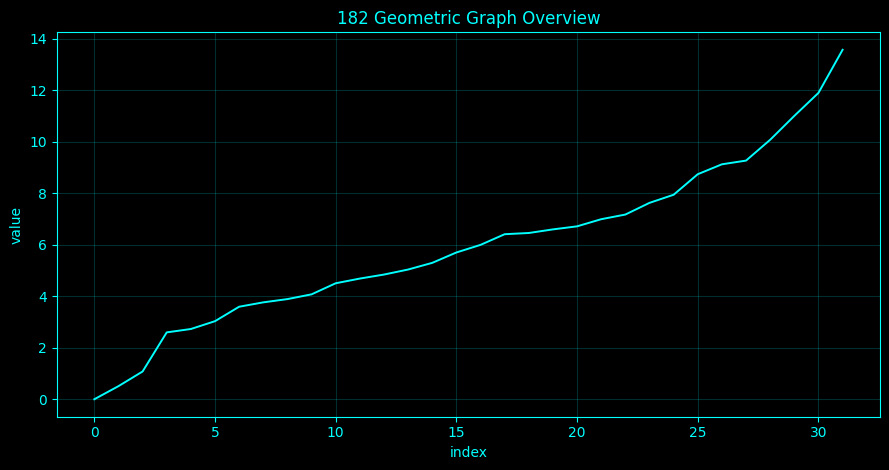

,laplacian_eigenvalue
0,-2.206797e-15
1,5.082413e-01
2,1.077657e+00
3,2.596387e+00
4,2.727246e+00
5,3.031315e+00
6,3.592277e+00
7,3.761923e+00
8,3.888527e+00
9,4.073077e+00


In [187]:
L=np.diag(W0.sum(1))-W0;evals,evecs=np.linalg.eigh(L);grsave('182_geometric_graph_overview',pd.DataFrame({'laplacian_eigenvalue':evals}))

### Geometric Laplacian eigenmaps

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Geometric Laplacian eigenmaps</h3><p>Laplacian eigenmaps use the nonconstant eigenvectors of the generalized problem L v=lambda D v. The embedding preserves strong local edges by minimizing sum w_ij||y_i-y_j||^2.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$Lv=\lambda Dv.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


channel       LE1       LE2       LE3
    Fp1  0.036033 -0.093897  0.092973
    Fpz -0.059083  0.059687  0.055129
    Fp2 -0.048499  0.066606 -0.004260
     F7  0.129395 -0.004510  0.123507
     F3 -0.032118 -0.113402 -0.073681
     Fz -0.022729 -0.109470 -0.029022
     F4 -0.029405 -0.104567 -0.044231
     F8 -0.036686 -0.088617 -0.048039
    FC5  0.085638 -0.049635  0.120167
    FC1 -0.050031 -0.007092 -0.000249
    FC2 -0.003014 -0.116763  0.022981
    FC6 -0.057264  0.065581  0.046161


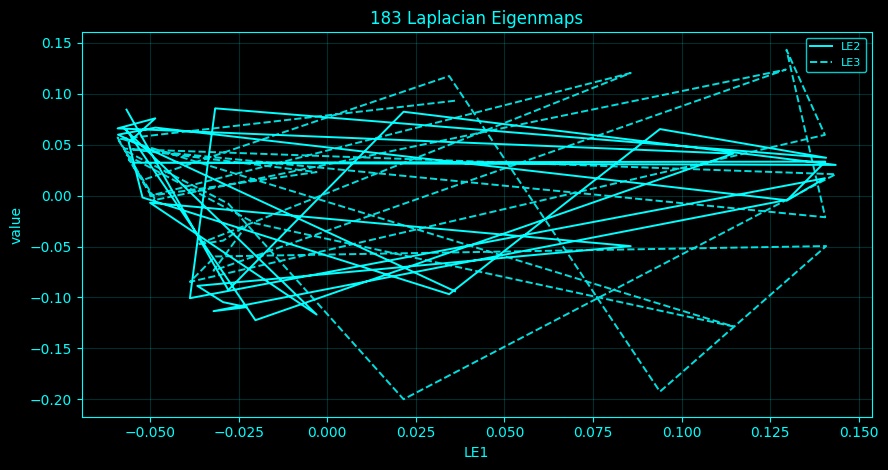

,channel,LE1,LE2,LE3
0,Fp1,0.036033,-0.093897,0.092973
1,Fpz,-0.059083,0.059687,0.055129
2,Fp2,-0.048499,0.066606,-0.004260
3,F7,0.129395,-0.004510,0.123507
4,F3,-0.032118,-0.113402,-0.073681
5,Fz,-0.022729,-0.109470,-0.029022
6,F4,-0.029405,-0.104567,-0.044231
7,F8,-0.036686,-0.088617,-0.048039
8,FC5,0.085638,-0.049635,0.120167
9,FC1,-0.050031,-0.007092,-0.000249


In [190]:
deg=W0.sum(1);Di=np.diag(1/np.sqrt(deg+EPS));Ln=Di@L@Di;la,U=np.linalg.eigh((Ln+Ln.T)/2);Ylap=Di@U[:,1:4];grsave('183_laplacian_eigenmaps',pd.DataFrame({'channel':eeg_channel_names,'LE1':Ylap[:,0],'LE2':Ylap[:,1],'LE3':Ylap[:,2]}))

### Diffusion geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Diffusion geometry</h3><p>The continuous-time heat kernel exp(-tL_rw) defines diffusion coordinates. Eigenmodes are exponentially damped according to their Laplacian eigenvalues.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$H_t=e^{-tL},\qquad \phi_k(t)=e^{-t\lambda_k}\phi_k.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


channel  heat_self_return
    Fp1          0.606775
    Fpz          0.508334
    Fp2          0.336531
     F7          0.444647
     F3          0.404783
     Fz          0.464464
     F4          0.286062
     F8          0.275017
    FC5          0.509964
    FC1          0.164037
    FC2          0.383315
    FC6          0.227253


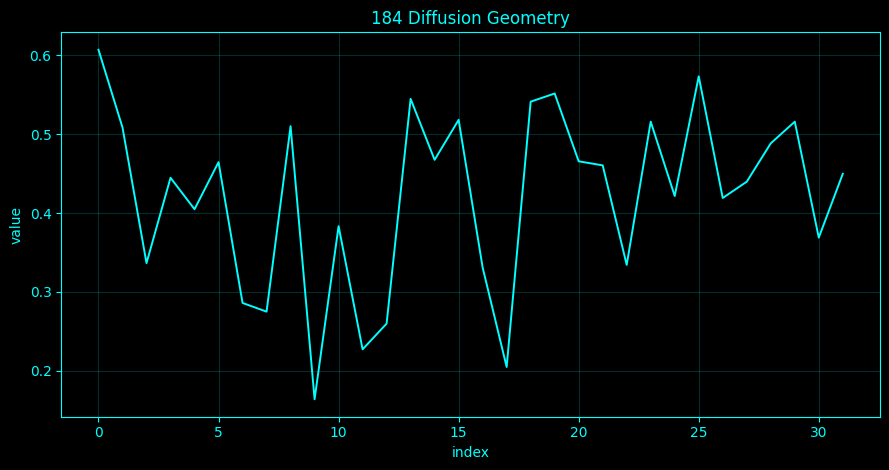

,channel,heat_self_return
0,Fp1,0.606775
1,Fpz,0.508334
2,Fp2,0.336531
3,F7,0.444647
4,F3,0.404783
5,Fz,0.464464
6,F4,0.286062
7,F8,0.275017
8,FC5,0.509964
9,FC1,0.164037


In [191]:
t0=1/max(np.median(evals[1:]),EPS);H=expm(-t0*L);grsave('184_diffusion_geometry',pd.DataFrame({'channel':eeg_channel_names,'heat_self_return':np.diag(H)}))

### Diffusion distance

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Diffusion distance</h3><p>Diffusion distance is the Euclidean distance between heat-kernel rows at a fixed diffusion time, comparing full diffusion profiles rather than direct graph paths.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$D_t^2(i,j)=\sum_k(H_t(i,k)-H_t(j,k))^2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


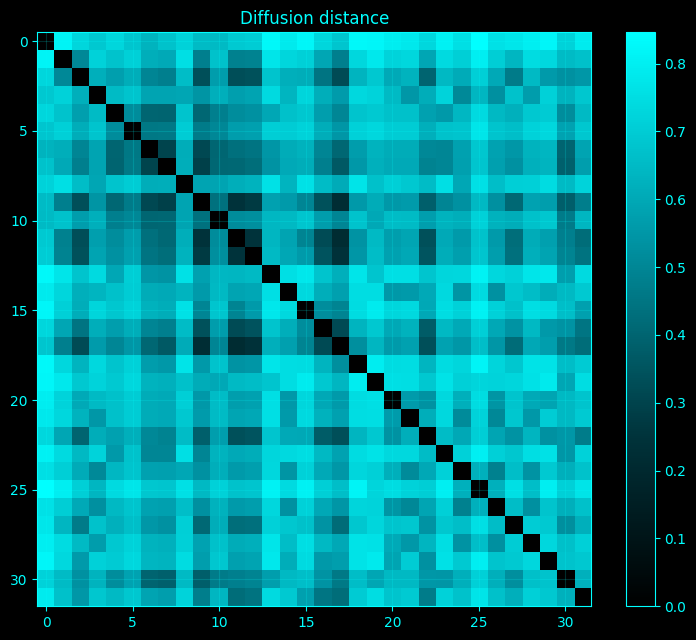

array([[0.        , 0.81627106, 0.73017785, ..., 0.82254524, 0.72031755,
        0.78748873],
       [0.81627106, 0.        , 0.5066194 , ..., 0.73390138, 0.65240052,
        0.66770034],
       [0.73017785, 0.5066194 , 0.        , ..., 0.56157066, 0.53381893,
        0.54905436],
       ...,
       [0.82254524, 0.73390138, 0.56157066, ..., 0.        , 0.67486152,
        0.68879306],
       [0.72031755, 0.65240052, 0.53381893, ..., 0.67486152, 0.        ,
        0.62402124],
       [0.78748873, 0.66770034, 0.54905436, ..., 0.68879306, 0.62402124,
        0.        ]])

In [192]:
DDIF=cdist(H,H);emit_matrix('185_diffusion_distance','Diffusion distance',DDIF,eeg_channel_names)

### Diffusion curvature

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Diffusion curvature</h3><p>There is no single canonical scalar called diffusion curvature on arbitrary weighted graphs. This cell explicitly uses local heat-kernel concentration relative to neighboring concentration as a diffusion-curvature proxy.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$K_i^{diff,proxy}=H_t(i,i)-\sum_jP_{ij}H_t(j,j).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


channel  diffusion_curvature_proxy
    Fp1                   0.187808
    Fpz                   0.268461
    Fp2                   0.008785
     F7                  -0.049712
     F3                   0.033092
     Fz                   0.117625
     F4                  -0.131556
     F8                  -0.107631
    FC5                   0.033790
    FC1                  -0.199071
    FC2                  -0.040871
    FC6                  -0.137209


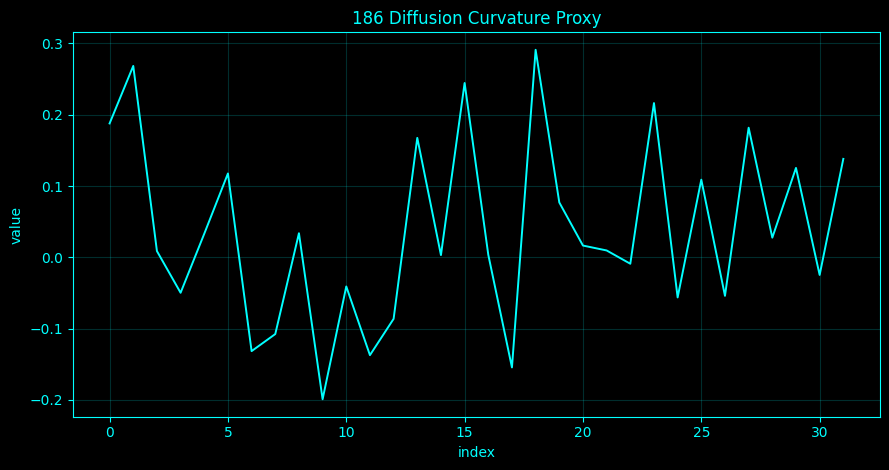

,channel,diffusion_curvature_proxy
0,Fp1,0.187808
1,Fpz,0.268461
2,Fp2,0.008785
3,F7,-0.049712
4,F3,0.033092
5,Fz,0.117625
6,F4,-0.131556
7,F8,-0.107631
8,FC5,0.033790
9,FC1,-0.199071


In [193]:
P=np.divide(W0,W0.sum(1)[:,None],out=np.zeros_like(W0),where=W0.sum(1)[:,None]>0);hd=np.diag(H);kc=hd-P@hd;grsave('186_diffusion_curvature_proxy',pd.DataFrame({'channel':eeg_channel_names,'diffusion_curvature_proxy':kc}))

### Heat-kernel geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Heat-kernel geometry</h3><p>The heat kernel is the matrix exponential of the weighted combinatorial Laplacian and solves dH/dt=-LH with H(0)=I. Diagonal values are return densities and off-diagonal values encode diffusion connectivity.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$H_t=e^{-tL}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


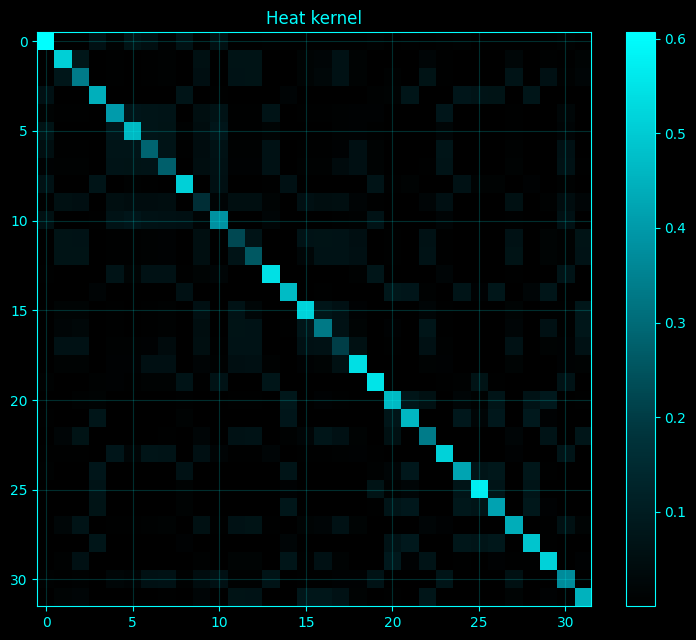

array([[6.06775153e-01, 4.06093950e-04, 4.18442917e-04, ...,
        2.32589725e-04, 7.66468603e-03, 1.00868493e-04],
       [4.06093950e-04, 5.08333735e-01, 7.99951256e-02, ...,
        7.18998658e-03, 5.50944781e-03, 1.61311295e-02],
       [4.18442917e-04, 7.99951256e-02, 3.36531153e-01, ...,
        6.06445157e-02, 8.68020270e-03, 2.05853938e-02],
       ...,
       [2.32589725e-04, 7.18998658e-03, 6.06445157e-02, ...,
        5.15713052e-01, 7.13970666e-04, 1.14905801e-02],
       [7.66468603e-03, 5.50944781e-03, 8.68020270e-03, ...,
        7.13970666e-04, 3.68823604e-01, 1.92563839e-03],
       [1.00868493e-04, 1.61311295e-02, 2.05853938e-02, ...,
        1.14905801e-02, 1.92563839e-03, 4.49619074e-01]])

In [194]:
emit_matrix('187_heat_kernel_geometry','Heat kernel',H,eeg_channel_names)

### Commute-time geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Commute-time geometry</h3><p>For a connected conductance graph, commute time equals graph volume times effective resistance. The relation is exact for the random walk associated with the conductances.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$C_{ij}=vol(G)R_{ij},\quad vol(G)=\sum_i d_i.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


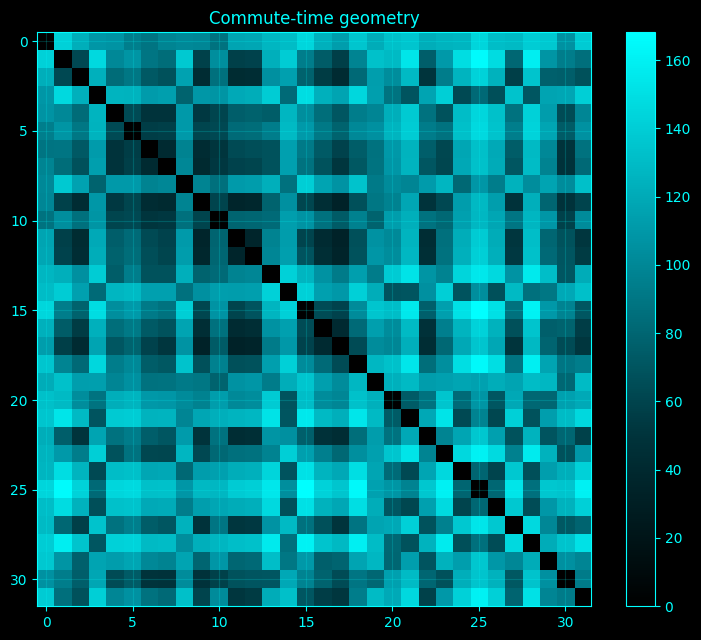

array([[  0.        , 142.22384168, 122.75268307, ..., 136.93784377,
        106.00084173, 138.90507107],
       [142.22384168,   0.        ,  62.41341531, ..., 108.26156858,
         94.32701625,  85.95214398],
       [122.75268307,  62.41341531,   0.        , ...,  77.17734368,
         76.17202676,  68.17526189],
       ...,
       [136.93784377, 108.26156858,  77.17734368, ...,   0.        ,
        105.18182664,  99.07935964],
       [106.00084173,  94.32701625,  76.17202676, ..., 105.18182664,
          0.        ,  92.71098372],
       [138.90507107,  85.95214398,  68.17526189, ...,  99.07935964,
         92.71098372,   0.        ]])

In [195]:
Lp=np.linalg.pinv(L);diag=np.diag(Lp);RES=diag[:,None]+diag[None,:]-2*Lp;VOL=W0.sum();COMM=VOL*RES;emit_matrix('188_commute_time_geometry','Commute-time geometry',COMM,eeg_channel_names)

### Resistance-distance geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Resistance-distance geometry</h3><p>Effective resistance is the quadratic form of the Laplacian pseudoinverse and is a metric on connected undirected graphs.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$R_{ij}=(e_i-e_j)^TL^+(e_i-e_j).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


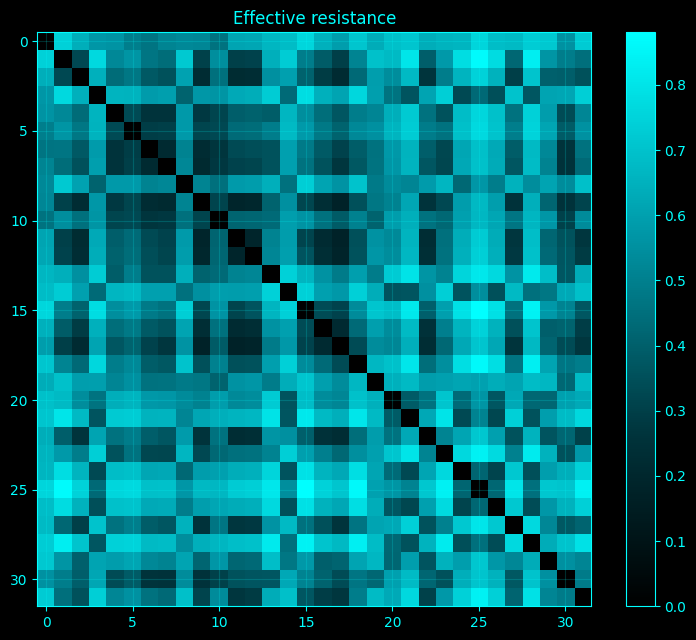

array([[0.        , 0.74513392, 0.64312134, ..., 0.71743971, 0.55535571,
        0.72774634],
       [0.74513392, 0.        , 0.32699407, ..., 0.56720003, 0.49419463,
        0.45031731],
       [0.64312134, 0.32699407, 0.        , ..., 0.4043447 , 0.39907768,
        0.35718132],
       ...,
       [0.71743971, 0.56720003, 0.4043447 , ..., 0.        , 0.55106475,
        0.51909293],
       [0.55535571, 0.49419463, 0.39907768, ..., 0.55106475, 0.        ,
        0.48572797],
       [0.72774634, 0.45031731, 0.35718132, ..., 0.51909293, 0.48572797,
        0.        ]])

In [196]:
emit_matrix('189_resistance_distance','Effective resistance',RES,eeg_channel_names)

### Effective resistance embedding

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Effective resistance embedding</h3><p>If L=U Lambda U^T, mapping vertex i to coordinates U_ik/sqrt(lambda_k) embeds squared Euclidean distance exactly as effective resistance.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$\|z_i-z_j\|^2=R_{ij}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 max_squared_distance_identity_error  embedding_dimension
                        5.662137e-15                   31


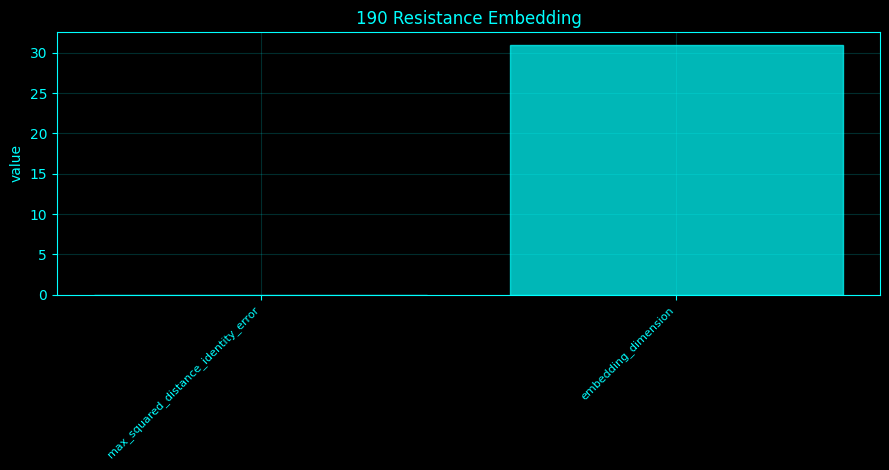

,max_squared_distance_identity_error,embedding_dimension
0,5.662137e-15,31


In [197]:
pos=evals>1e-9;ER=evecs[:,pos]/np.sqrt(evals[pos])[None,:];err=np.max(np.abs(cdist(ER,ER)**2-RES));grsave('190_resistance_embedding',pd.DataFrame({'max_squared_distance_identity_error':[err],'embedding_dimension':[ER.shape[1]]}))

### Spectral embedding geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Spectral embedding geometry</h3><p>The first nonconstant normalized-Laplacian eigenvectors provide a global spectral embedding ordered by increasing smoothness energy.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$y_i=(u_2(i),u_3(i),u_4(i)).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


channel         x         y         z
    Fp1  0.036033 -0.093897  0.092973
    Fpz -0.059083  0.059687  0.055129
    Fp2 -0.048499  0.066606 -0.004260
     F7  0.129395 -0.004510  0.123507
     F3 -0.032118 -0.113402 -0.073681
     Fz -0.022729 -0.109470 -0.029022
     F4 -0.029405 -0.104567 -0.044231
     F8 -0.036686 -0.088617 -0.048039
    FC5  0.085638 -0.049635  0.120167
    FC1 -0.050031 -0.007092 -0.000249
    FC2 -0.003014 -0.116763  0.022981
    FC6 -0.057264  0.065581  0.046161


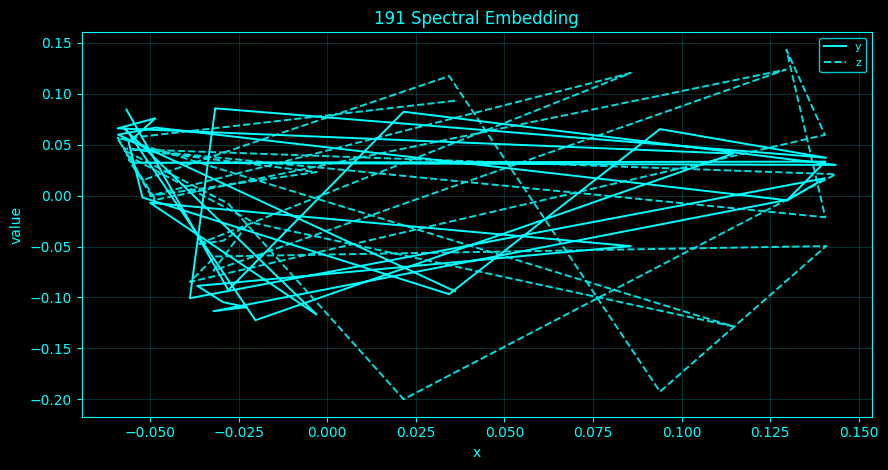

,channel,x,y,z
0,Fp1,0.036033,-0.093897,0.092973
1,Fpz,-0.059083,0.059687,0.055129
2,Fp2,-0.048499,0.066606,-0.004260
3,F7,0.129395,-0.004510,0.123507
4,F3,-0.032118,-0.113402,-0.073681
5,Fz,-0.022729,-0.109470,-0.029022
6,F4,-0.029405,-0.104567,-0.044231
7,F8,-0.036686,-0.088617,-0.048039
8,FC5,0.085638,-0.049635,0.120167
9,FC1,-0.050031,-0.007092,-0.000249


In [198]:
grsave('191_spectral_embedding',pd.DataFrame({'channel':eeg_channel_names,'x':Ylap[:,0],'y':Ylap[:,1],'z':Ylap[:,2]}))

### Graph geodesic embedding

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Graph geodesic embedding</h3><p>Classical multidimensional scaling is applied to squared graph shortest-path distances. Positive eigenvalues of the double-centered Gram matrix yield Euclidean coordinates approximating the graph metric.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$B=-\tfrac12JD_G^{\circ2}J.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


channel         x         y         z
    Fp1 -0.995865 -1.803122  1.545173
    Fpz  1.809078  0.828111 -0.142136
    Fp2  0.961858  1.123704 -0.073161
     F7 -2.808278 -1.185225  0.991532
     F3  1.475869 -1.380521  0.159353
     Fz  0.811828 -1.290336  0.939846
     F4  1.084149 -1.346778  0.735434
     F8  1.321189 -0.944917  0.227697
    FC5 -1.939860 -1.495874  0.258490
    FC1  1.585630 -0.193026 -0.242561
    FC2 -0.034766 -1.716708  0.257832
    FC6  1.377779  1.230453  0.152018


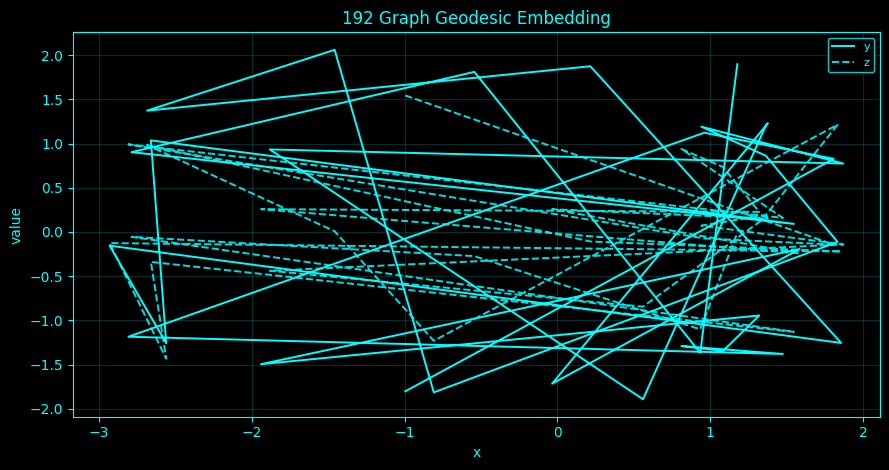

,channel,x,y,z
0,Fp1,-0.995865,-1.803122,1.545173
1,Fpz,1.809078,0.828111,-0.142136
2,Fp2,0.961858,1.123704,-0.073161
3,F7,-2.808278,-1.185225,0.991532
4,F3,1.475869,-1.380521,0.159353
5,Fz,0.811828,-1.290336,0.939846
6,F4,1.084149,-1.346778,0.735434
7,F8,1.321189,-0.944917,0.227697
8,FC5,-1.939860,-1.495874,0.258490
9,FC1,1.585630,-0.193026,-0.242561


In [199]:
Jc=np.eye(nC)-np.ones((nC,nC))/nC;B=-.5*Jc@(GD*GD)@Jc;w,U=np.linalg.eigh((B+B.T)/2);ord=np.argsort(w)[::-1];w=w[ord];U=U[:,ord];pos=w>1e-10;Yg=U[:,pos][:,:3]*np.sqrt(w[pos][:3]);grsave('192_graph_geodesic_embedding',pd.DataFrame({'channel':eeg_channel_names,'x':Yg[:,0],'y':Yg[:,1],'z':Yg[:,2]}))

### Graph geodesic centrality

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Graph geodesic centrality</h3><p>Geodesic closeness centrality is the reciprocal mean shortest-path distance to all other vertices. It is a metric centrality rather than an edge-count degree measure.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$c_i=(n-1)/\sum_{j
e i}d_G(i,j).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


channel  geodesic_closeness
    Fp1            0.321704
    Fpz            0.340058
    Fp2            0.396061
     F7            0.293934
     F3            0.364513
     Fz            0.372308
     F4            0.397577
     F8            0.405882
    FC5            0.329048
    FC1            0.430571
    FC2            0.373446
    FC6            0.401105


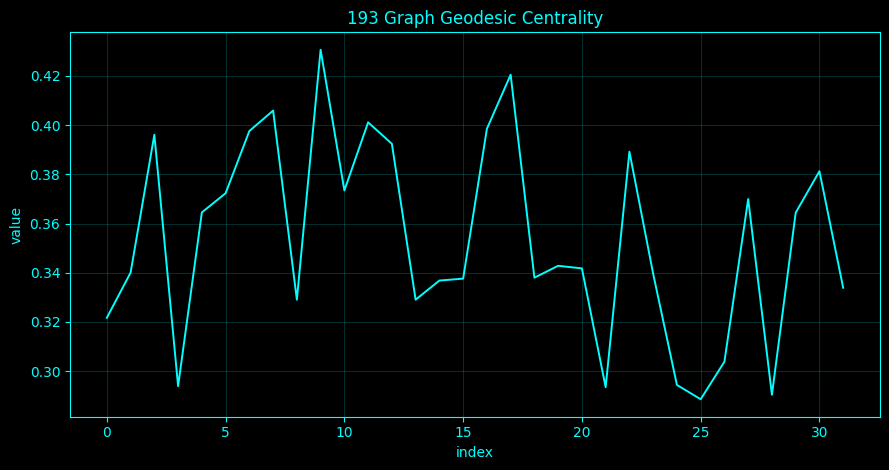

,channel,geodesic_closeness
0,Fp1,0.321704
1,Fpz,0.340058
2,Fp2,0.396061
3,F7,0.293934
4,F3,0.364513
5,Fz,0.372308
6,F4,0.397577
7,F8,0.405882
8,FC5,0.329048
9,FC1,0.430571


In [200]:
cl=(nC-1)/(GD.sum(1)+EPS);grsave('193_graph_geodesic_centrality',pd.DataFrame({'channel':eeg_channel_names,'geodesic_closeness':cl}))

### Graph geodesic convexity

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Graph geodesic convexity</h3><p>A vertex set is geodesically convex if every shortest path between vertices in the set remains in the set. The finite cell reports the fraction of regional pairs whose one reconstructed shortest path stays inside the region.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$C(S)=P[path_G(i,j)\subset S\mid i,j\in S].$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 region  shortest_path_convex_fraction
   left                       0.448718
  right                       0.525641
midline                       0.066667


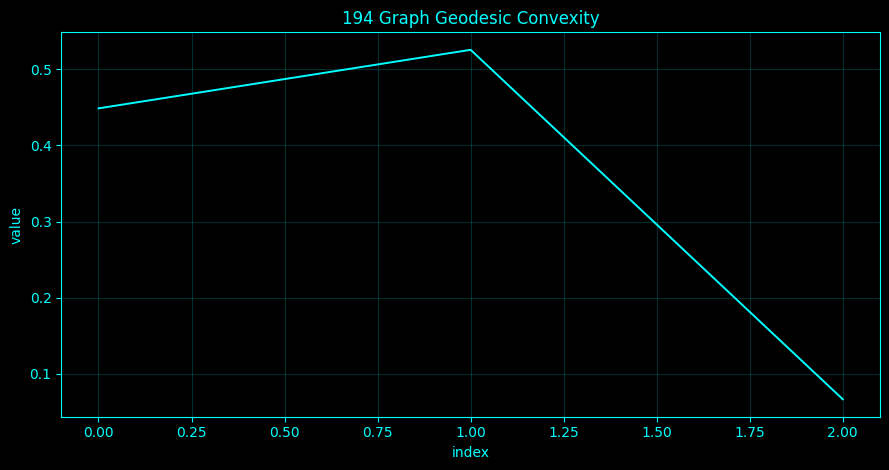

,region,shortest_path_convex_fraction
0,left,0.448718
1,right,0.525641
2,midline,0.066667


In [201]:
def one_path(W,s,t):
 D=graph_dist(W);path=[t];cur=t
 while cur!=s:
  cand=np.where(W[cur]>0)[0];vals=[D[s,v]+lengths(W)[v,cur] for v in cand];cur=int(cand[int(np.argmin(vals))]);path.append(cur)
  if len(path)>nC+2:break
 return path[::-1]
rows=[]
for name,S in {'left':LEFT,'right':RIGHT,'midline':MID}.items():
 ok=[]
 for a0 in range(len(S)):
  for b0 in range(a0+1,len(S)):ok.append(set(one_path(W0,S[a0],S[b0])).issubset(set(S)))
 rows.append((name,np.mean(ok) if ok else np.nan))
grsave('194_graph_geodesic_convexity',pd.DataFrame(rows,columns=['region','shortest_path_convex_fraction']))

### Graph Voronoi regions

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Graph Voronoi regions</h3><p>Graph Voronoi cells assign each vertex to the seed with smallest shortest-path distance. Seeds are chosen as the most geodesically central channels within left, right and midline regions.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$V_s=\{v:d_G(v,s)\le d_G(v,s')\;\forall s'\}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [202]:
regions={'left':LEFT,'right':RIGHT,'midline':MID};seeds=[max(v,key=lambda i:cl[i]) for v in regions.values()];assign=np.argmin(GD[:,seeds],axis=1);grsave('195_graph_voronoi',pd.DataFrame({'channel':eeg_channel_names,'voronoi_seed':[eeg_channel_names[seeds[a]] for a in assign]}))

channel voronoi_seed
    Fp1          FC1
    Fpz          FC1
    Fp2          FC1
     F7           Oz
     F3          FC1
     Fz          FC1
     F4          FC1
     F8          FC1
    FC5           Oz
    FC1          FC1
    FC2           Oz
    FC6           T8


,channel,voronoi_seed
0,Fp1,FC1
1,Fpz,FC1
2,Fp2,FC1
3,F7,Oz
4,F3,FC1
5,Fz,FC1
6,F4,FC1
7,F8,FC1
8,FC5,Oz
9,FC1,FC1


### Graph Delaunay-like neighborhoods

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Graph Delaunay-like neighborhoods</h3><p>The dual of graph Voronoi cells is formed by connecting seed regions whenever an original graph edge crosses between their Voronoi cells. This is explicitly Delaunay-like, not Euclidean Delaunay triangulation.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$s\sim_D s'\iff\exists(u,v)\in E:\;u\in V_s,v\in V_{s'}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


In [203]:
pairs=set()
for i,j,_ in E0:
 a,b=int(assign[i]),int(assign[j]);
 if a!=b:pairs.add(tuple(sorted((a,b))))
grsave('196_graph_delaunay_like',pd.DataFrame([(eeg_channel_names[seeds[a]],eeg_channel_names[seeds[b]]) for a,b in sorted(pairs)],columns=['seed_a','seed_b']))

seed_a seed_b
   FC1     T8
   FC1     Oz
    T8     Oz


,seed_a,seed_b
0,FC1,T8
1,FC1,Oz
2,T8,Oz


### Geometric graph sparsification

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Geometric graph sparsification</h3><p>Effective-resistance leverage scores w_e R_e govern spectral sparsification. Edges are sampled independently with probability proportional to leverage and reweighted by 1/p_e; the leverage sum is checked against n-1.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$\sum_e w_eR_e=n-1.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 trial  sampled_edges  algebraic_connectivity  leverage_sum  expected_n_minus_1
     0             68                0.473636          31.0                  31
     1             62                0.451859          31.0                  31
     2             55                0.473010          31.0                  31
     3             58                0.166187          31.0                  31


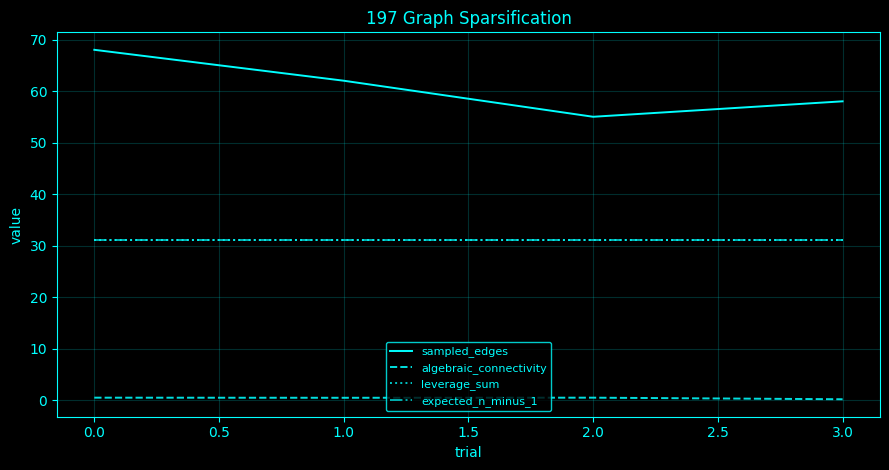

,trial,sampled_edges,algebraic_connectivity,leverage_sum,expected_n_minus_1
0,0,68,0.473636,31.0,31
1,1,62,0.451859,31.0,31
2,2,55,0.473010,31.0,31
3,3,58,0.166187,31.0,31


In [204]:
lev=[]
for i,j,w in E0:lev.append((i,j,w,w*RES[i,j]));ls=sum(x[3] for x in lev);target=max(nC-1,int(.55*len(lev)));rows=[]
for trial in range(GR_CFG['sparse_trials']):
 WS=np.zeros_like(W0)
 for i,j,w,l in lev:
  p=min(1,target*l/(ls+EPS));
  if RNG.random()<p:WS[i,j]=WS[j,i]=w/(p+EPS)
 rows.append((trial,np.count_nonzero(np.triu(WS,1)),algconn(WS)))
grsave('197_graph_sparsification',pd.DataFrame(rows,columns=['trial','sampled_edges','algebraic_connectivity']).assign(leverage_sum=ls,expected_n_minus_1=nC-1))

### Geometric spanner analysis

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Geometric spanner analysis</h3><p>A greedy t-spanner processes candidate edges from shortest to longest and inserts an edge only when current graph distance exceeds t times that edge length. The resulting graph is checked for maximum stretch.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$d_H(u,v)\le t\,d_G(u,v).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 target_stretch  observed_max_stretch  spanner_edges
            1.5                   1.0            114


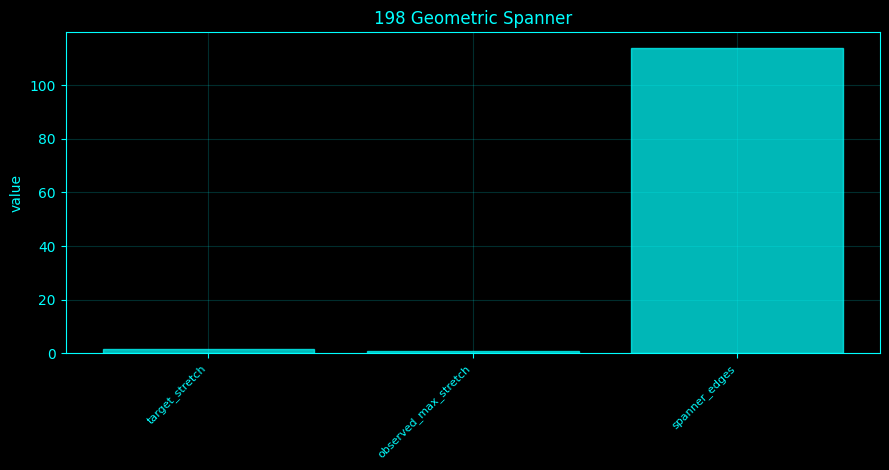

,target_stretch,observed_max_stretch,spanner_edges
0,1.5,1.0,114


In [205]:
tsp=1.5;EL=sorted([(i,j,lengths(W0)[i,j]) for i,j,_ in E0],key=lambda z:z[2]);LS=np.full_like(W0,np.inf);np.fill_diagonal(LS,0)
for i,j,l in EL:
 Dcur=_gshort(csr_matrix(LS),directed=False)
 if not np.isfinite(Dcur[i,j]) or Dcur[i,j]>tsp*l:LS[i,j]=LS[j,i]=l
DS=_gshort(csr_matrix(LS),directed=False);m=(GD>0)&np.isfinite(GD)&np.isfinite(DS);stretch=np.max(DS[m]/GD[m]);grsave('198_geometric_spanner',pd.DataFrame({'target_stretch':[tsp],'observed_max_stretch':[stretch],'spanner_edges':[np.count_nonzero(np.triu(np.isfinite(LS)&(LS>0),1))]}))

### Manifold-aware kNN graph optimization

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Manifold-aware kNN graph optimization</h3><p>Candidate kNN graphs on the PCA state cloud are scored by connected-pair geodesic distortion plus a degree penalty. The selected k is therefore data-adaptive while the objective is stated explicitly.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$J(k)=median(d_G/d_E)+0.01k.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 k  objective  finite_fraction
 3   1.582233         0.722222
 4   1.384329         0.722222
 5   1.273623         0.722222
 6   1.280505         1.000000
 7   1.228326         1.000000
 8   1.203218         1.000000
 9   1.195716         1.000000
10   1.192213         1.000000
11   1.186861         1.000000
12   1.182341         1.000000
13   1.177743         1.000000
14   1.176740         1.000000


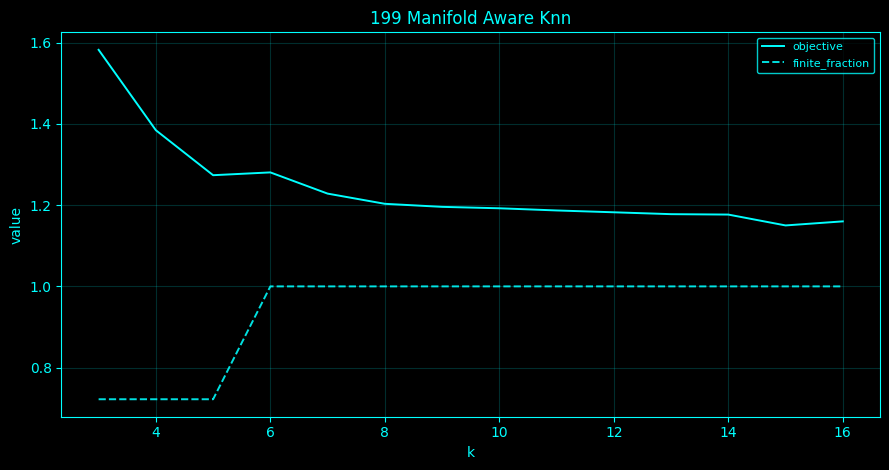

selected k 15


In [206]:
rows=[]
for kk in range(3,min(16,len(DE)-1)+1):
 Gk=geod_matrix(DE,kk);m=(DE>0)&np.isfinite(Gk);rat=Gk[m]/DE[m];rows.append((kk,np.median(rat)+.01*kk,np.mean(np.isfinite(Gk))))
df=pd.DataFrame(rows,columns=['k','objective','finite_fraction']);grsave('199_manifold_aware_knn',df);print('selected k',int(df.loc[df.objective.idxmin(),'k']))

### Local-to-global graph geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Local-to-global graph geometry</h3><p>Local edge lengths and global shortest-path distances are compared through the ratio of mean all-pairs graph distance to mean direct edge length. This summarizes how local geometry accumulates globally without being a universal invariant.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$G/L=\langle d_G(i,j)\rangle_{i<j}/\langle \ell_e\rangle_e.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 mean_global_geodesic  mean_local_edge_length  global_to_local_ratio
             2.865844                1.207864               2.372654


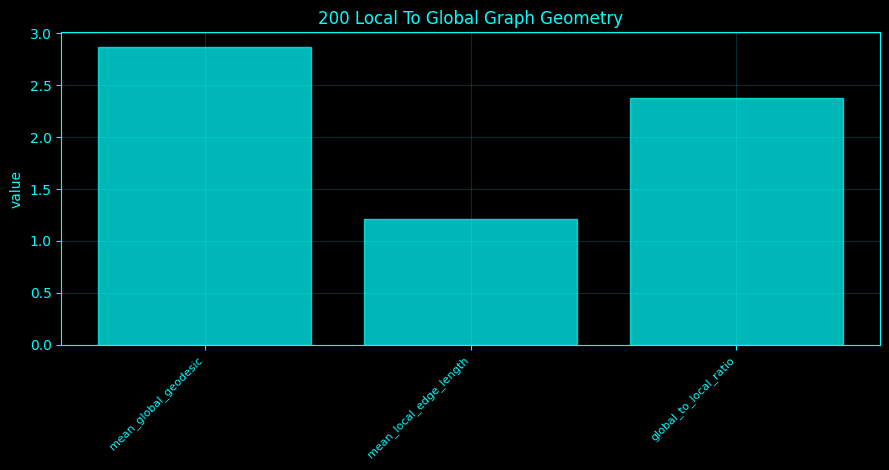

,mean_global_geodesic,mean_local_edge_length,global_to_local_ratio
0,2.865844,1.207864,2.372654


In [207]:
tri=np.triu_indices(nC,1);glob=np.mean(GD[tri]);loc=np.mean([lengths(W0)[i,j] for i,j,_ in E0]);grsave('200_local_to_global_graph_geometry',pd.DataFrame({'mean_global_geodesic':[glob],'mean_local_edge_length':[loc],'global_to_local_ratio':[glob/(loc+EPS)]}))

# Geometry catalogue continuation — entries 201–225

Hyperbolic and spherical geometry of EEG-derived channel/state representations.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Shared hyperbolic and spherical foundation</h3><p>Hyperbolic calculations use the Poincaré disk of curvature -1 together with its isometric Lorentz hyperboloid representation. Channel spectral features are mapped inside the disk only as a finite embedding; the geometry itself is exact once coordinates are chosen. Spherical calculations use genuine unit vectors: instantaneous multichannel analytic phases become points on a high-dimensional unit sphere after concatenating cosine and sine components and normalizing. Great-circle distances, log/exp maps and Karcher means are therefore evaluated on actual constant-curvature manifolds.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$d_{\mathbb D}(x,y)=\operatorname{arcosh}\!\left(1+\frac{2\|x-y\|^2}{(1-\|x\|^2)(1-\|y\|^2)}\right),\quad d_{S}(x,y)=\arccos(x^Ty).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


Hyperbolic/spherical foundation: ultra phase states 260


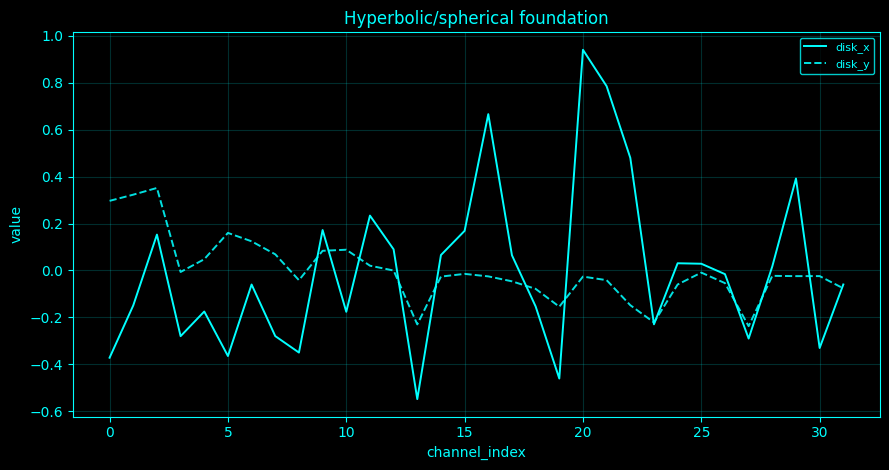

True

In [208]:
from scipy.optimize import minimize
HS_CFG={'full':dict(phase=1200,opt=500),'balanced':dict(phase=800,opt=350),'fast':dict(phase=500,opt=220),'ultra':dict(phase=260,opt=120)}[FAST_OPTION]
HS_OUT=os.path.join(base_dir,'results','geometry_catalogue_hyper_spherical');os.makedirs(HS_OUT,exist_ok=True)
def hsdir(s):d=os.path.join(HS_OUT,s);os.makedirs(d,exist_ok=True);return d
def hsave(s,df):df.to_csv(os.path.join(hsdir(s),f'{s}_{FAST_OPTION}.csv'),index=False);print(df.head(12).to_string(index=False));catalogue_autoplot_df(s,df);return df
def mobius_add(x,y):
 x=np.asarray(x,float);y=np.asarray(y,float);xy=x@y;xx=x@x;yy=y@y;den=1+2*xy+xx*yy;return ((1+2*xy+yy)*x+(1-xx)*y)/(den+EPS)
def mobius_scalar(t,x):
 x=np.asarray(x,float);r=np.linalg.norm(x)
 if r<EPS:return x.copy()
 return np.tanh(float(t)*np.arctanh(min(r,1-1e-12)))*x/r
def pdist_h(x,y):
 x=np.asarray(x,float);y=np.asarray(y,float);xx=x@x;yy=y@y;z=1+2*np.sum((x-y)**2)/((1-xx)*(1-yy)+EPS);return float(np.arccosh(max(z,1)))
def pgeo(x,y,t):return mobius_add(x,mobius_scalar(t,mobius_add(-x,y)))
def lorentz_lift(x):
 r2=float(x@x);d=1-r2;return np.r_[(1+r2)/d,2*x/d]
def linner(x,y):return float(-x[0]*y[0]+x[1:]@y[1:])
def ldist(x,y):return float(np.arccosh(max(-linner(x,y),1)))
def hmatrix(X):return np.array([[pdist_h(a,b) for b in X] for a in X])
def hfrechet(X):
 x0=np.mean(X,axis=0);x0=x0/max(1,np.linalg.norm(x0)/.75)
 def obj(z):
  r=np.linalg.norm(z)
  if r>=.999:return 1e6+1e6*(r-.999)**2
  return float(np.mean([pdist_h(z,x)**2 for x in X]))
 res=minimize(obj,x0,method='Nelder-Mead',options={'maxiter':HS_CFG['opt'],'xatol':1e-8,'fatol':1e-8});z=res.x;z=z/max(1,np.linalg.norm(z)/.995);return z,res
# channel spectral feature embedding -> disk
F=np.log(BP.T+EPS);F=(F-F.mean(0))/(F.std(0)+EPS);U,s,Vt=np.linalg.svd(F-F.mean(0),full_matrices=False);Y=U[:,:2]*s[:2];rad=np.linalg.norm(Y,axis=1);scale=np.quantile(rad,.95)+EPS;HD=Y/scale*.72;rr=np.linalg.norm(HD,axis=1);HD[rr>=.94]*=(.94/rr[rr>=.94])[:,None];HYPD=hmatrix(HD);LOR=np.stack([lorentz_lift(x) for x in HD])
# spherical analytic phase states
ph=np.angle(signal.hilbert(EEG_STD,axis=0));idx=np.unique(np.linspace(0,len(ph)-1,min(len(ph),HS_CFG['phase'])).round().astype(int));SPH=np.concatenate([np.cos(ph[idx]),np.sin(ph[idx])],axis=1)/np.sqrt(nC);ST=start_time+idx/sampling_rate
def sdist(x,y):return float(np.arccos(np.clip(np.asarray(x)@np.asarray(y),-1,1)))
def slogmap(mu,x):
 c=np.clip(mu@x,-1,1);th=np.arccos(c);v=x-c*mu;n=np.linalg.norm(v);return np.zeros_like(mu) if n<EPS else th*v/n
def sexpmap_s(mu,v):
 th=np.linalg.norm(v);return mu.copy() if th<EPS else np.cos(th)*mu+np.sin(th)*v/th
def skarcher(X):
 mu=np.mean(X,axis=0);mu/=np.linalg.norm(mu)+EPS
 for _ in range(80):
  v=np.mean([slogmap(mu,x) for x in X],axis=0)
  if np.linalg.norm(v)<1e-9:break
  mu=sexpmap_s(mu,v);mu/=np.linalg.norm(mu)+EPS
 return mu
def slerp(x,y,t):
 th=sdist(x,y)
 if th<1e-10:return x.copy()
 return np.sin((1-t)*th)/np.sin(th)*x+np.sin(t*th)/np.sin(th)*y
SMU=skarcher(SPH)
print('Hyperbolic/spherical foundation:',FAST_OPTION,'phase states',len(SPH))
# Visible foundation diagnostic
catalogue_autoplot_df('hyperbolic_spherical_foundation',pd.DataFrame({'channel_index':np.arange(len(HD)),'disk_x':HD[:,0],'disk_y':HD[:,1]}),title='Hyperbolic/spherical foundation')


### Hyperbolic geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Hyperbolic geometry</h3><p>The Poincaré disk carries the complete constant-curvature -1 metric. Hyperbolic distances between the finite channel embedding points are computed from the exact disk formula.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$ds^2=4\,\|dx\|^2/(1-\|x\|^2)^2,\qquad K=-1.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


 mean_pair_distance  max_pair_distance  curvature
           1.101789           4.800943       -1.0


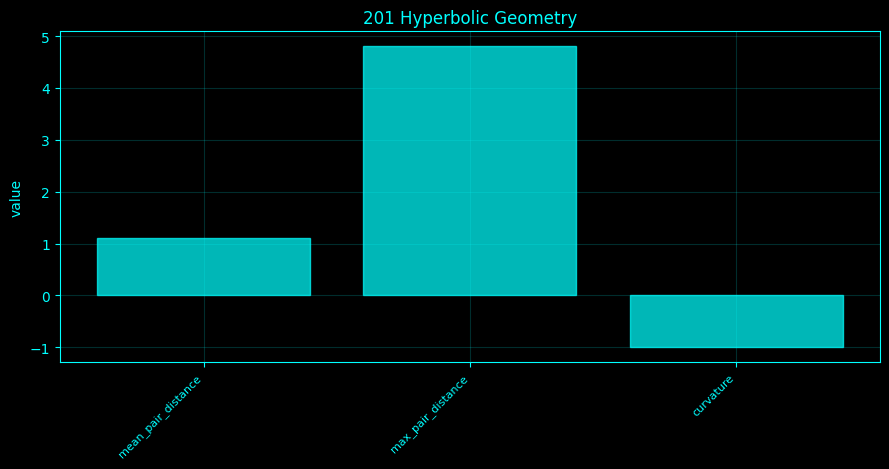

,mean_pair_distance,max_pair_distance,curvature
0,1.101789,4.800943,-1.0


In [209]:
hsave('201_hyperbolic_geometry',pd.DataFrame({'mean_pair_distance':[HYPD[np.triu_indices(nC,1)].mean()],'max_pair_distance':[HYPD.max()],'curvature':[-1.0]}))

### Hyperbolic embedding of EEG channels

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Hyperbolic embedding of EEG channels</h3><p>Standardized log band-power features are reduced to two PCA coordinates and radially placed inside the Poincaré disk. The embedding map is data driven; subsequent distances use exact hyperbolic geometry.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$x_c\in\mathbb D^2=\{x:\|x\|<1\}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


channel         x         y   radius
    Fp1 -0.371399  0.296485 0.475227
    Fpz -0.148789  0.322829 0.355467
    Fp2  0.152804  0.351416 0.383200
     F7 -0.279640 -0.006350 0.279712
     F3 -0.174702  0.047964 0.181167
     Fz -0.364217  0.159978 0.397803
     F4 -0.059765  0.124169 0.137803
     F8 -0.279428  0.068852 0.287785
    FC5 -0.349453 -0.041365 0.351893
    FC1  0.172263  0.083839 0.191581
    FC2 -0.175924  0.088426 0.196897
    FC6  0.233780  0.020450 0.234673


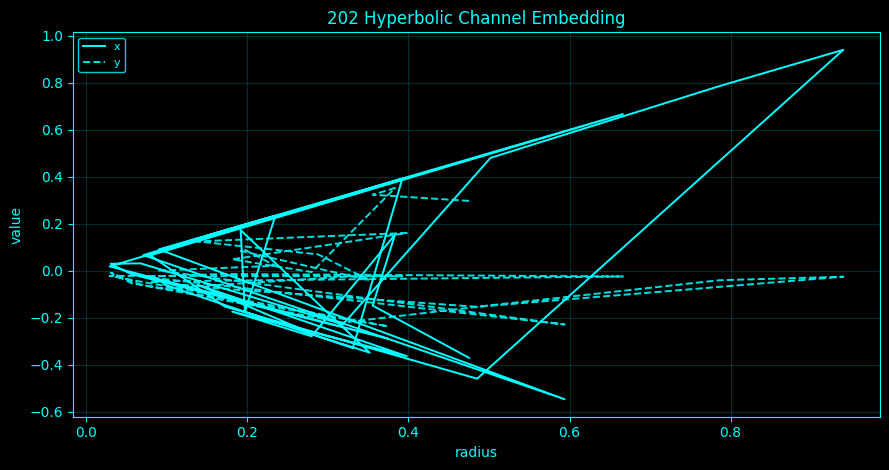

,channel,x,y,radius
0,Fp1,-0.371399,0.296485,0.475227
1,Fpz,-0.148789,0.322829,0.355467
2,Fp2,0.152804,0.351416,0.383200
3,F7,-0.279640,-0.006350,0.279712
4,F3,-0.174702,0.047964,0.181167
5,Fz,-0.364217,0.159978,0.397803
6,F4,-0.059765,0.124169,0.137803
7,F8,-0.279428,0.068852,0.287785
8,FC5,-0.349453,-0.041365,0.351893
9,FC1,0.172263,0.083839,0.191581


In [210]:
hsave('202_hyperbolic_channel_embedding',pd.DataFrame({'channel':eeg_channel_names,'x':HD[:,0],'y':HD[:,1],'radius':np.linalg.norm(HD,axis=1)}))

### Poincaré disk embedding

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Poincaré disk embedding</h3><p>The Poincaré disk is conformal: Euclidean and hyperbolic angles agree, while radial distances diverge near the boundary. All embedded radii are explicitly checked to remain below one.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$d(0,x)=2\operatorname{artanh}\|x\|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


channel   radius  distance_from_origin
    Fp1 0.475227              1.033601
    Fpz 0.355467              0.743375
    Fp2 0.383200              0.807611
     F7 0.279712              0.574739
     F3 0.181167              0.366377
     Fz 0.397803              0.842072
     F4 0.137803              0.277372
     F8 0.287785              0.592300
    FC5 0.351893              0.735205
    FC1 0.191581              0.387956
    FC2 0.196897              0.399004
    FC6 0.234673              0.478258


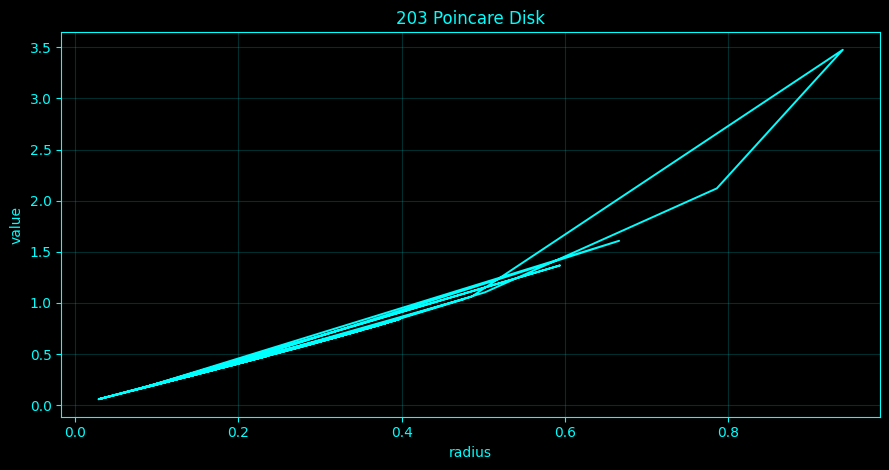

,channel,radius,distance_from_origin
0,Fp1,0.475227,1.033601
1,Fpz,0.355467,0.743375
2,Fp2,0.383200,0.807611
3,F7,0.279712,0.574739
4,F3,0.181167,0.366377
5,Fz,0.397803,0.842072
6,F4,0.137803,0.277372
7,F8,0.287785,0.592300
8,FC5,0.351893,0.735205
9,FC1,0.191581,0.387956


In [211]:
hsave('203_poincare_disk',pd.DataFrame({'channel':eeg_channel_names,'radius':np.linalg.norm(HD,axis=1),'distance_from_origin':[pdist_h(np.zeros(2),x) for x in HD]}))

### Lorentz-model hyperbolic embedding

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Lorentz-model hyperbolic embedding</h3><p>The standard disk-to-hyperboloid lift is an isometry from the Poincaré disk to the upper sheet of the Lorentz hyperboloid. Each lifted point satisfies Minkowski norm -1.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$X=((1+\|x\|^2)/(1-\|x\|^2),\,2x/(1-\|x\|^2)),\quad\langle X,X\rangle_L=-1.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


channel       x0        x1        x2  minkowski_norm
    Fp1 1.583448 -0.959491  0.765952            -1.0
    Fpz 1.289263 -0.340617  0.739040            -1.0
    Fp2 1.344233  0.358208  0.823802            -1.0
     F7 1.169759 -0.606751 -0.013778            -1.0
     F3 1.067870 -0.361261  0.099183            -1.0
     Fz 1.375994 -0.865378  0.380106            -1.0
     F4 1.038715 -0.121843  0.253145            -1.0
     F8 1.180598 -0.609319  0.150139            -1.0
    FC5 1.282658 -0.797681 -0.094423            -1.0
    FC1 1.076204  0.357652  0.174066            -1.0
    FC2 1.080664 -0.366039  0.183984            -1.0
    FC6 1.116562  0.494811  0.043285            -1.0


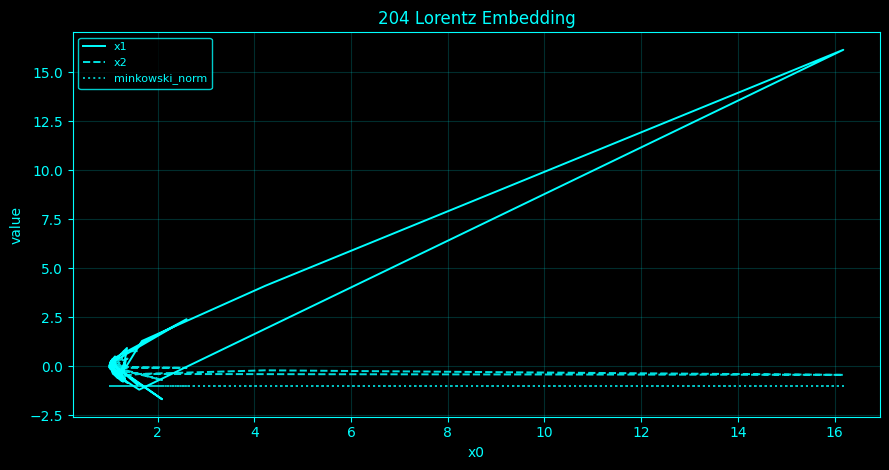

,channel,x0,x1,x2,minkowski_norm
0,Fp1,1.583448,-0.959491,0.765952,-1.0
1,Fpz,1.289263,-0.340617,0.739040,-1.0
2,Fp2,1.344233,0.358208,0.823802,-1.0
3,F7,1.169759,-0.606751,-0.013778,-1.0
4,F3,1.067870,-0.361261,0.099183,-1.0
5,Fz,1.375994,-0.865378,0.380106,-1.0
6,F4,1.038715,-0.121843,0.253145,-1.0
7,F8,1.180598,-0.609319,0.150139,-1.0
8,FC5,1.282658,-0.797681,-0.094423,-1.0
9,FC1,1.076204,0.357652,0.174066,-1.0


In [212]:
hsave('204_lorentz_embedding',pd.DataFrame({'channel':eeg_channel_names,'x0':LOR[:,0],'x1':LOR[:,1],'x2':LOR[:,2],'minkowski_norm':[linner(x,x) for x in LOR]}))

### Hyperbolic distance matrices

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Hyperbolic distance matrices</h3><p>Poincaré and Lorentz formulas are isometric representations of the same curvature -1 space. The cell reports their matrix agreement as a numerical identity check.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$d_{\mathbb H}(X,Y)=\operatorname{arcosh}(-\langle X,Y\rangle_L).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


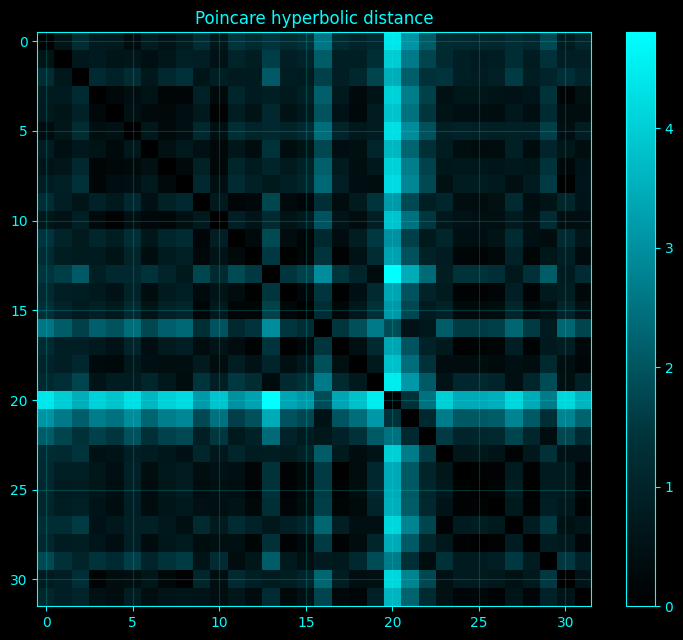

 max_poincare_lorentz_error
               3.371748e-07


,max_poincare_lorentz_error
0,3.371748e-07


In [213]:
DL=np.array([[ldist(a,b) for b in LOR] for a in LOR]);emit_matrix('205_hyperbolic_distance_matrix','Poincare hyperbolic distance',HYPD,eeg_channel_names);hsave('205_hyperbolic_distance_identity',pd.DataFrame({'max_poincare_lorentz_error':[np.max(np.abs(HYPD-DL))]}))

### Hyperbolic curvature fit

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Hyperbolic curvature fit</h3><p>Scaling a Riemannian metric by s squared changes sectional curvature from -1 to -1/s squared. A least-squares scale aligns hyperbolic channel distances to functional-graph shortest-path distances, yielding a model curvature estimate without changing the disk formula.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$d_s=s\,d_{-1},\qquad K_s=-1/s^2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Regression fits a mathematical relationship between predictors and an outcome by choosing coefficients that minimize a loss, usually squared error. Ridge regression adds a penalty on large coefficients, which can stabilize estimates when predictors are correlated or data are limited. The coefficient of determination R² summarizes how much of the observed variance is explained by the fitted relationship within the analyzed data, but a high R² does not prove causality or guarantee good out-of-sample prediction.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


 metric_scale  fitted_constant_curvature  normalized_stress
     1.639228                  -0.372153           0.664702


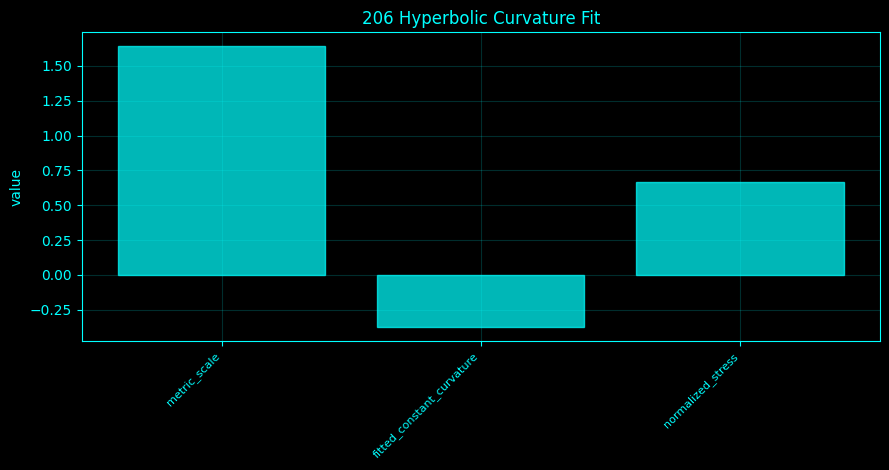

,metric_scale,fitted_constant_curvature,normalized_stress
0,1.639228,-0.372153,0.664702


In [214]:
tri=np.triu_indices(nC,1);a=HYPD[tri];b=GD[tri];sc=float((a@b)/(a@a+EPS));hsave('206_hyperbolic_curvature_fit',pd.DataFrame({'metric_scale':[sc],'fitted_constant_curvature':[-1/(sc*sc+EPS)],'normalized_stress':[np.linalg.norm(sc*a-b)/(np.linalg.norm(b)+EPS)]}))

### Tree-likeness via hyperbolic distortion

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Tree-likeness via hyperbolic distortion</h3><p>Hyperbolic spaces naturally embed tree-like metrics. The cell compares optimally scaled hyperbolic and Euclidean feature distances against the same graph-geodesic target using normalized stress.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$stress=\min_s\|sD_{embed}-D_G\|_F/\|D_G\|_F.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 euclidean_stress  hyperbolic_stress
         0.587521           0.664702


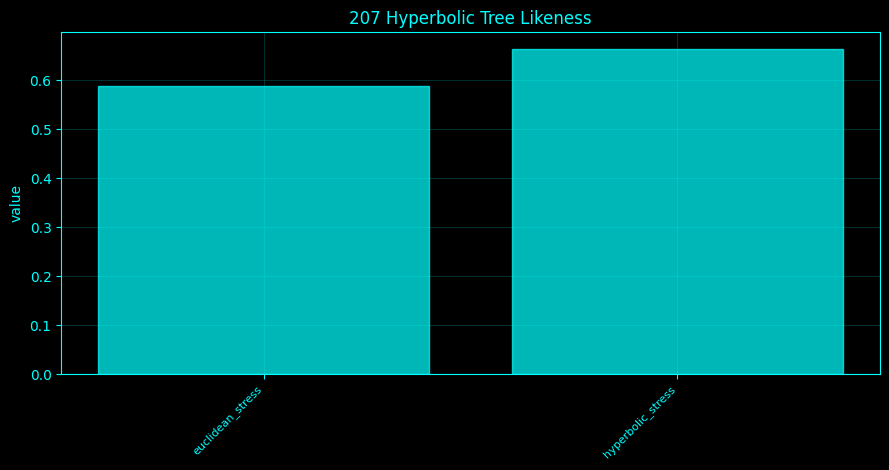

,euclidean_stress,hyperbolic_stress
0,0.587521,0.664702


In [215]:
EUC=cdist(HD,HD);ae=EUC[tri];se=float((ae@b)/(ae@ae+EPS));sh=float((a@b)/(a@a+EPS));hsave('207_hyperbolic_tree_likeness',pd.DataFrame({'euclidean_stress':[np.linalg.norm(se*ae-b)/(np.linalg.norm(b)+EPS)],'hyperbolic_stress':[np.linalg.norm(sh*a-b)/(np.linalg.norm(b)+EPS)]}))

### Hyperbolic community geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Hyperbolic community geometry</h3><p>Existing curvature-aware graph communities are summarized by their Poincaré centroids and radial dispersion. Euclidean averaging is used only to summarize coordinates, not as a hyperbolic barycenter.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$r_c=\|x_c\|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 community  n  mean_radius  std_radius
         1  3     0.368944    0.080724
         2  8     0.296378    0.347618
         3  9     0.325561    0.140186
         4 12     0.276235    0.174939


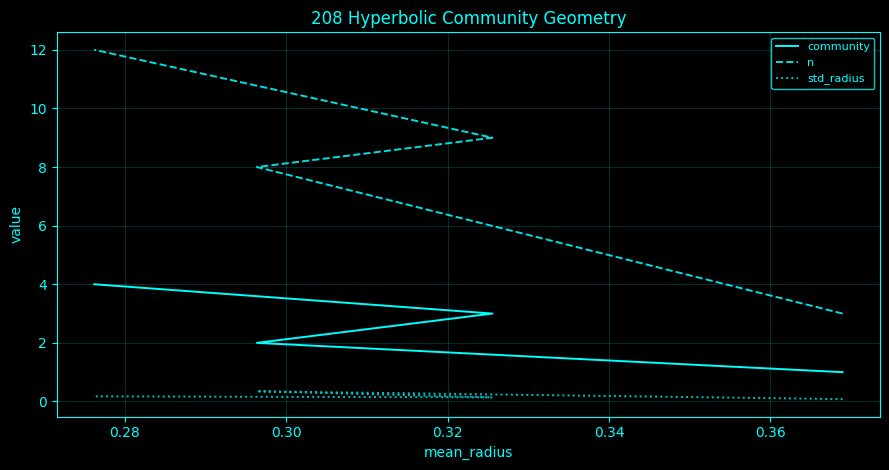

,community,n,mean_radius,std_radius
0,1,3,0.368944,0.080724
1,2,8,0.296378,0.347618
2,3,9,0.325561,0.140186
3,4,12,0.276235,0.174939


In [216]:
labs=np.asarray(lab);rows=[]
for g in np.unique(labs):
 X=HD[labs==g];rows.append((int(g),len(X),float(np.mean(np.linalg.norm(X,axis=1))),float(np.std(np.linalg.norm(X,axis=1)))))
hsave('208_hyperbolic_community_geometry',pd.DataFrame(rows,columns=['community','n','mean_radius','std_radius']))

### Hyperbolic hierarchy detection

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Hyperbolic hierarchy detection</h3><p>In many hyperbolic network models, smaller radial coordinate corresponds to higher hierarchy or popularity. The cell reports radius together with graph geodesic closeness and their rank correlation; it does not assume the model is physically true.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$r_i=\|x_i\|,\quad h_i\propto-r_i.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The proportionality symbol means the two quantities are expected to follow the same scaling law up to a multiplicative constant.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


channel   radius  geodesic_closeness  radius_closeness_spearman
    Fp1 0.475227            0.321704                   0.172654
    Fpz 0.355467            0.340058                   0.172654
    Fp2 0.383200            0.396061                   0.172654
     F7 0.279712            0.293934                   0.172654
     F3 0.181167            0.364513                   0.172654
     Fz 0.397803            0.372308                   0.172654
     F4 0.137803            0.397577                   0.172654
     F8 0.287785            0.405882                   0.172654
    FC5 0.351893            0.329048                   0.172654
    FC1 0.191581            0.430571                   0.172654
    FC2 0.196897            0.373446                   0.172654
    FC6 0.234673            0.401105                   0.172654


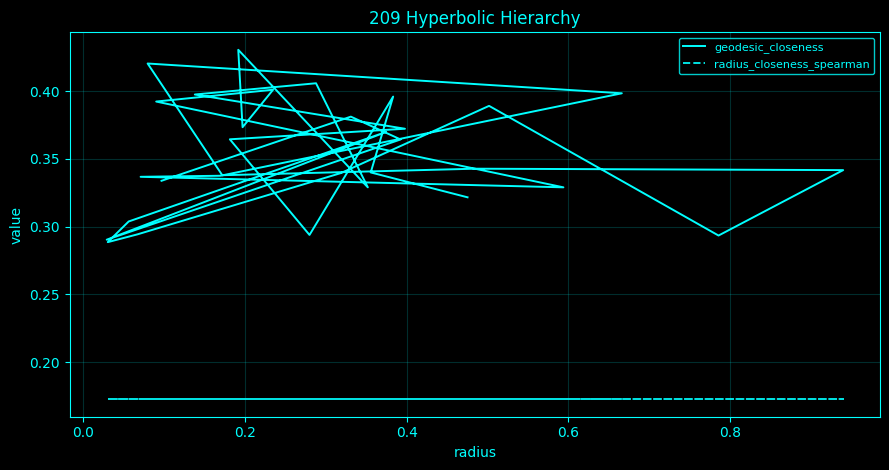

,channel,radius,geodesic_closeness,radius_closeness_spearman
0,Fp1,0.475227,0.321704,0.172654
1,Fpz,0.355467,0.340058,0.172654
2,Fp2,0.383200,0.396061,0.172654
3,F7,0.279712,0.293934,0.172654
4,F3,0.181167,0.364513,0.172654
5,Fz,0.397803,0.372308,0.172654
6,F4,0.137803,0.397577,0.172654
7,F8,0.287785,0.405882,0.172654
8,FC5,0.351893,0.329048,0.172654
9,FC1,0.191581,0.430571,0.172654


In [217]:
rho=spearmanr(np.linalg.norm(HD,axis=1),cl).statistic;hsave('209_hyperbolic_hierarchy',pd.DataFrame({'channel':eeg_channel_names,'radius':np.linalg.norm(HD,axis=1),'geodesic_closeness':cl}).assign(radius_closeness_spearman=rho))

### Hyperbolic graph embedding

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Hyperbolic graph embedding</h3><p>Classical graph-geodesic MDS coordinates are radially compressed into the Poincaré disk, producing a graph-driven finite embedding. This is an explicit construction rather than a claim of globally optimal hyperbolic embedding.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$x=z/(a+\|z\|),\quad\|x\|<1.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


channel         x         y
    Fp1 -0.169858 -0.307546
    Fpz  0.312974  0.143265
    Fp2  0.185696  0.216942
     F7 -0.399719 -0.168700
     F3  0.253712 -0.237321
     Fz  0.155134 -0.246573
     F4  0.198069 -0.246050
     F8  0.246926 -0.176602
    FC5 -0.306867 -0.236633
    FC1  0.298118 -0.036291
    FC2 -0.006368 -0.314436
    FC6  0.245471  0.219223


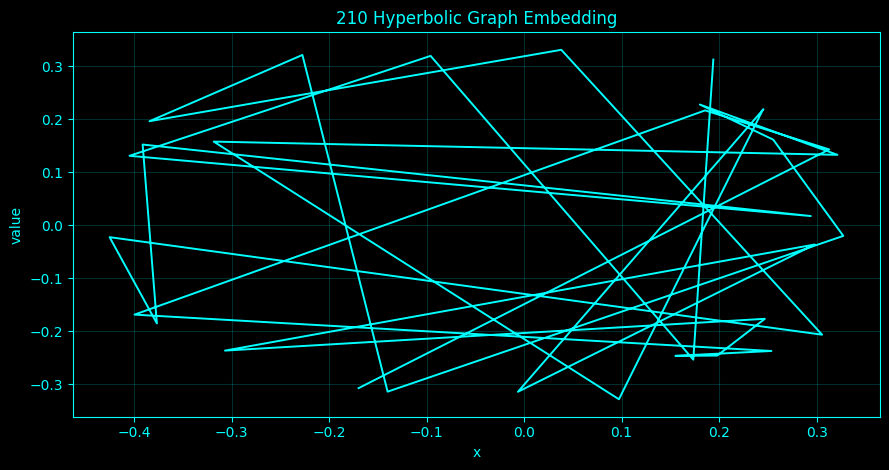

,channel,x,y
0,Fp1,-0.169858,-0.307546
1,Fpz,0.312974,0.143265
2,Fp2,0.185696,0.216942
3,F7,-0.399719,-0.168700
4,F3,0.253712,-0.237321
5,Fz,0.155134,-0.246573
6,F4,0.198069,-0.246050
7,F8,0.246926,-0.176602
8,FC5,-0.306867,-0.236633
9,FC1,0.298118,-0.036291


In [218]:
ZG=Yg[:,:2];scg=np.quantile(np.linalg.norm(ZG,axis=1),.9)+EPS;HG=ZG/(scg+np.linalg.norm(ZG,axis=1)[:,None]);HG*=.85;hsave('210_hyperbolic_graph_embedding',pd.DataFrame({'channel':eeg_channel_names,'x':HG[:,0],'y':HG[:,1]}))

### Hyperbolic geodesic interpolation

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Hyperbolic geodesic interpolation</h3><p>Poincaré geodesics are generated with Möbius addition and scalar multiplication. This gives constant hyperbolic speed between the selected endpoint channels.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$\gamma(t)=x\oplus\big(t\otimes((-x)\oplus y)\big).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


   t  distance_from_start  expected  disk_radius
0.00             0.000000  0.000000     0.475227
0.05             0.052967  0.052967     0.454736
0.10             0.105935  0.105935     0.433792
0.15             0.158902  0.158902     0.412419
0.20             0.211869  0.211869     0.390644
0.25             0.264837  0.264837     0.368497
0.30             0.317804  0.317804     0.346017
0.35             0.370771  0.370771     0.323251
0.40             0.423739  0.423739     0.300255
0.45             0.476706  0.476706     0.277097
0.50             0.529674  0.529674     0.253867
0.55             0.582641  0.582641     0.230680


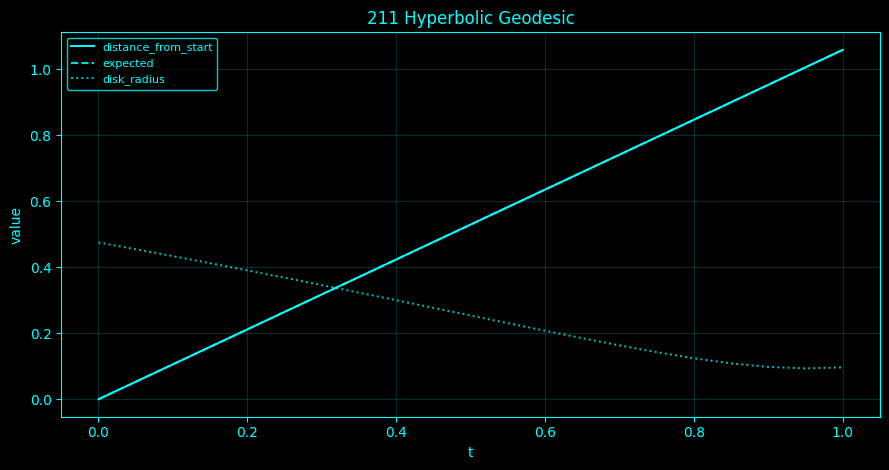

,t,distance_from_start,expected,disk_radius
0,0.00,0.000000,0.000000,0.475227
1,0.05,0.052967,0.052967,0.454736
2,0.10,0.105935,0.105935,0.433792
3,0.15,0.158902,0.158902,0.412419
4,0.20,0.211869,0.211869,0.390644
5,0.25,0.264837,0.264837,0.368497
6,0.30,0.317804,0.317804,0.346017
7,0.35,0.370771,0.370771,0.323251
8,0.40,0.423739,0.423739,0.300255
9,0.45,0.476706,0.476706,0.277097


In [219]:
x,y=HD[0],HD[-1];D=pdist_h(x,y);ts=np.linspace(0,1,21);rows=[]
for t in ts:z=pgeo(x,y,t);rows.append((t,pdist_h(x,z),t*D,np.linalg.norm(z)))
hsave('211_hyperbolic_geodesic',pd.DataFrame(rows,columns=['t','distance_from_start','expected','disk_radius']))

### Hyperbolic barycenters

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Hyperbolic barycenters</h3><p>The Fréchet mean minimizes the average squared hyperbolic distance. The cell obtains it by constrained numerical optimization inside the disk and reports the final Fréchet objective.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$\bar x=\arg\min_z N^{-1}\sum_i d_{\mathbb H}(z,x_i)^2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


       x        y   radius  frechet_objective  success
0.031489 -0.00147 0.031524           0.962658     True


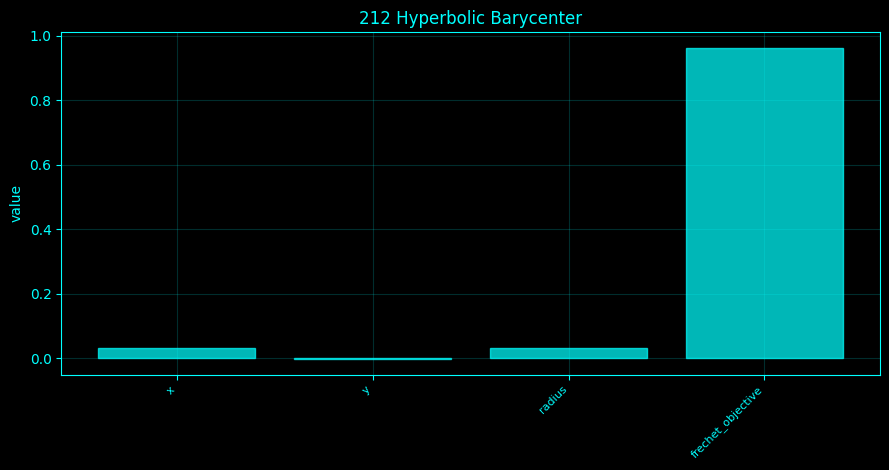

,x,y,radius,frechet_objective,success
0,0.031489,-0.00147,0.031524,0.962658,True


In [220]:
HB,res=hfrechet(HD);hsave('212_hyperbolic_barycenter',pd.DataFrame({'x':[HB[0]],'y':[HB[1]],'radius':[np.linalg.norm(HB)],'frechet_objective':[res.fun],'success':[res.success]}))

### Hyperbolic channel fingerprints

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Hyperbolic channel fingerprints</h3><p>Each channel fingerprint consists of disk radius, hyperbolic distance to the Fréchet mean and mean hyperbolic distance to all other channels. These features are invariant to the arbitrary ordering of channels.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$f_i=(\|x_i\|,d(x_i,\bar x),N^{-1}\sum_jd(x_i,x_j)).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


channel   radius  distance_to_barycenter  mean_pair_distance
    Fp1 0.475227                1.085510            1.253780
    Fpz 0.355467                0.774799            1.068391
    Fp2 0.383200                0.787858            1.162953
     F7 0.279712                0.637672            0.855334
     F3 0.181167                0.428141            0.768187
     Fz 0.397803                0.901283            1.063959
     F4 0.137803                0.312439            0.775169
     F8 0.287785                0.654301            0.873756
    FC5 0.351893                0.797500            0.956654
    FC1 0.191581                0.334034            0.844782
    FC2 0.196897                0.457373            0.789290
    FC6 0.234673                0.415846            0.889237


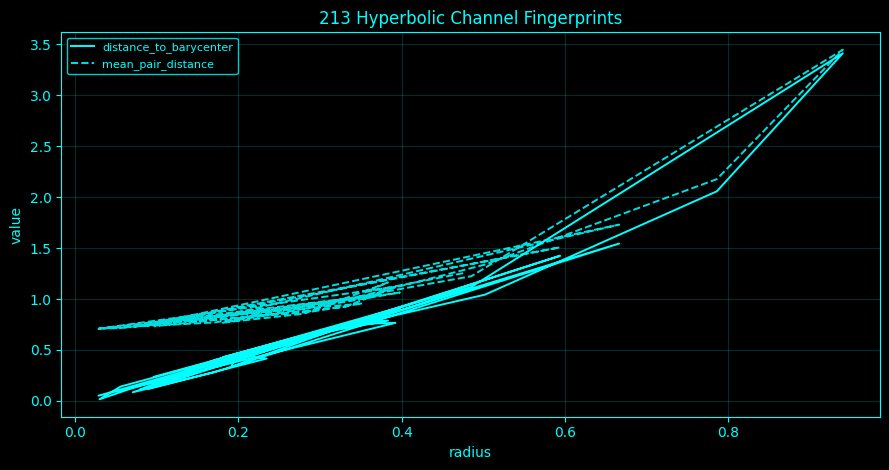

,channel,radius,distance_to_barycenter,mean_pair_distance
0,Fp1,0.475227,1.085510,1.253780
1,Fpz,0.355467,0.774799,1.068391
2,Fp2,0.383200,0.787858,1.162953
3,F7,0.279712,0.637672,0.855334
4,F3,0.181167,0.428141,0.768187
5,Fz,0.397803,0.901283,1.063959
6,F4,0.137803,0.312439,0.775169
7,F8,0.287785,0.654301,0.873756
8,FC5,0.351893,0.797500,0.956654
9,FC1,0.191581,0.334034,0.844782


In [221]:
hsave('213_hyperbolic_channel_fingerprints',pd.DataFrame({'channel':eeg_channel_names,'radius':np.linalg.norm(HD,axis=1),'distance_to_barycenter':[pdist_h(x,HB) for x in HD],'mean_pair_distance':HYPD.mean(1)}))

### Hyperbolic vs Euclidean embedding comparison

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Hyperbolic vs Euclidean embedding comparison</h3><p>Both Euclidean and hyperbolic feature embeddings are scaled optimally to the graph-geodesic metric before comparing stress, preventing arbitrary coordinate scale from deciding the result.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$stress(D)=\min_s\|sD-D_G\|/\|D_G\|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


  geometry  normalized_graph_stress
 Euclidean                 0.587521
Hyperbolic                 0.664702


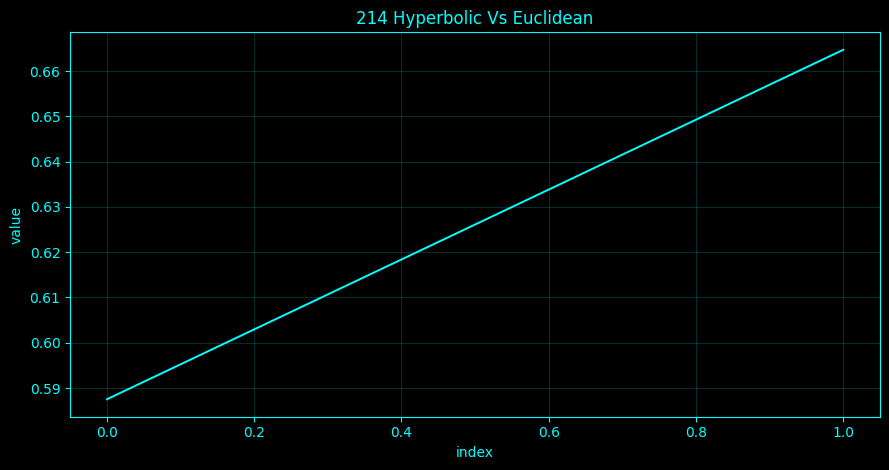

,geometry,normalized_graph_stress
0,Euclidean,0.587521
1,Hyperbolic,0.664702


In [222]:
hsave('214_hyperbolic_vs_euclidean',pd.DataFrame({'geometry':['Euclidean','Hyperbolic'],'normalized_graph_stress':[np.linalg.norm(se*ae-b)/(np.linalg.norm(b)+EPS),np.linalg.norm(sh*a-b)/(np.linalg.norm(b)+EPS)]}))

### Spherical geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Spherical geometry</h3><p>Concatenated cosine and sine channel phases have constant norm sqrt(nC); division by sqrt(nC) puts each instantaneous phase state exactly on the unit sphere.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$u(t)=n_C^{-1/2}(\cos\phi_1,\ldots,\cos\phi_n,\sin\phi_1,\ldots,\sin\phi_n),\quad\|u\|=1.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


 time_sec  unit_norm
  814.571        1.0
  814.984        1.0
  815.397        1.0
  815.810        1.0
  816.223        1.0
  816.636        1.0
  817.048        1.0
  817.461        1.0
  817.874        1.0
  818.287        1.0
  818.700        1.0
  819.113        1.0


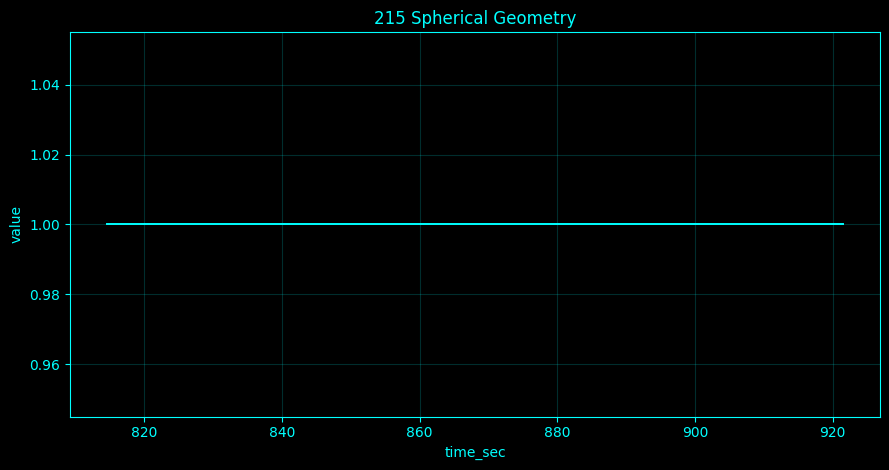

,time_sec,unit_norm
0,814.571,1.0
1,814.984,1.0
2,815.397,1.0
3,815.810,1.0
4,816.223,1.0
...,...,...
255,919.862,1.0
256,920.275,1.0
257,920.688,1.0
258,921.101,1.0


In [223]:
hsave('215_spherical_geometry',pd.DataFrame({'time_sec':ST,'unit_norm':np.linalg.norm(SPH,axis=1)}))

### Spherical embedding of phase states

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Spherical embedding of phase states</h3><p>The analytic-signal phase state is a true point on S^(2n-1), not a projected disk picture. The first three tangent PCA coordinates are used only for visualization downstream.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$u(t)\in S^{2n_C-1}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  distance_to_mean
  814.571          1.922170
  814.984          1.812785
  815.397          1.760416
  815.810          1.812474
  816.223          1.758162
  816.636          1.827672
  817.048          1.815816
  817.461          1.817459
  817.874          1.741669
  818.287          1.841777
  818.700          1.775169
  819.113          1.740433


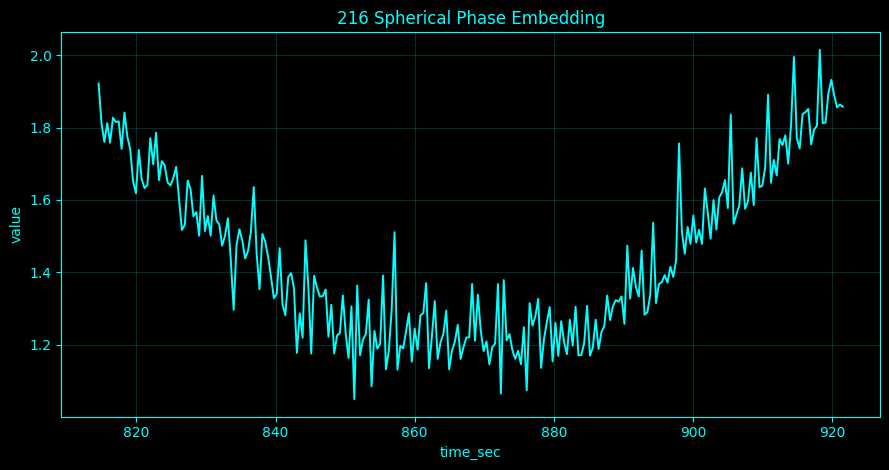

,time_sec,distance_to_mean
0,814.571,1.922170
1,814.984,1.812785
2,815.397,1.760416
3,815.810,1.812474
4,816.223,1.758162
...,...,...
255,919.862,1.932403
256,920.275,1.889369
257,920.688,1.856341
258,921.101,1.864139


In [224]:
hsave('216_spherical_phase_embedding',pd.DataFrame({'time_sec':ST,'distance_to_mean':[sdist(SMU,x) for x in SPH]}))

### Spherical geodesic distances

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Spherical geodesic distances</h3><p>Great-circle distance on the unit sphere is the angle arccos of the dot product. Consecutive phase-state angular increments are reported.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$d_S(x,y)=\arccos(x^Ty).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  great_circle_distance
  814.984               0.887799
  815.397               0.272689
  815.810               0.598902
  816.223               0.591706
  816.636               0.935373
  817.048               0.645526
  817.461               0.646853
  817.874               0.616391
  818.287               1.036402
  818.700               0.985635
  819.113               0.482179
  819.526               0.516005


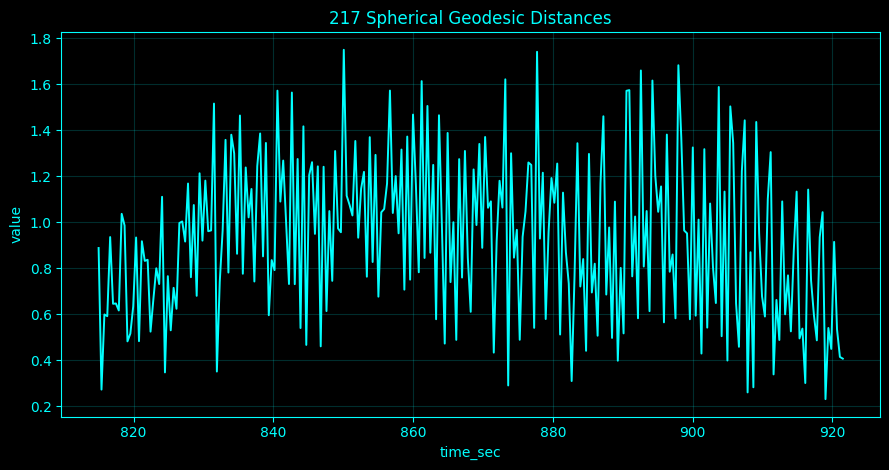

,time_sec,great_circle_distance
0,814.984,0.887799
1,815.397,0.272689
2,815.810,0.598902
3,816.223,0.591706
4,816.636,0.935373
...,...,...
254,919.862,0.449513
255,920.275,0.914351
256,920.688,0.534489
257,921.101,0.414564


In [225]:
d=np.array([sdist(SPH[i],SPH[i+1]) for i in range(len(SPH)-1)]);hsave('217_spherical_geodesic_distances',pd.DataFrame({'time_sec':ST[1:],'great_circle_distance':d}))

### Spherical barycenters

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Spherical barycenters</h3><p>The intrinsic Karcher mean iteratively averages logarithm-map tangent vectors and maps the update back with the spherical exponential.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$\bar x=\arg\min_x\sum_i d_S(x,x_i)^2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 component  mean_vector  norm
         0    -0.145402   1.0
         1    -0.154471   1.0
         2    -0.235349   1.0
         3     0.118027   1.0
         4     0.020266   1.0
         5     0.044572   1.0
         6    -0.047077   1.0
         7    -0.038869   1.0
         8     0.113227   1.0
         9    -0.123446   1.0
        10     0.051519   1.0
        11    -0.070581   1.0


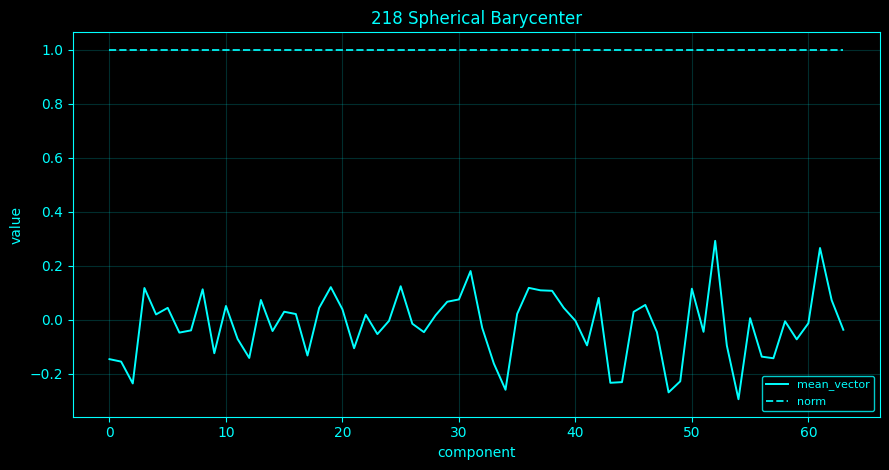

,component,mean_vector,norm
0,0,-0.145402,1.0
1,1,-0.154471,1.0
2,2,-0.235349,1.0
3,3,0.118027,1.0
4,4,0.020266,1.0
...,...,...,...
59,59,-0.072008,1.0
60,60,-0.012495,1.0
61,61,0.266180,1.0
62,62,0.073044,1.0


In [226]:
hsave('218_spherical_barycenter',pd.DataFrame({'component':np.arange(len(SMU)),'mean_vector':SMU}).assign(norm=np.linalg.norm(SMU)))

### Spherical PCA

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Spherical PCA</h3><p>Spherical PCA is performed in the tangent space at the Karcher mean. Log-mapped phase states satisfy v dot mu=0 and ordinary PCA then captures dominant small geodesic variations.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$v_i=\log_{\bar x}(x_i)\in T_{\bar x}S^{p-1}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 component  explained_fraction
         1            0.378062
         2            0.242779
         3            0.113790
         4            0.073114
         5            0.016973
         6            0.015080
         7            0.012575
         8            0.012162
         9            0.010274
        10            0.009019


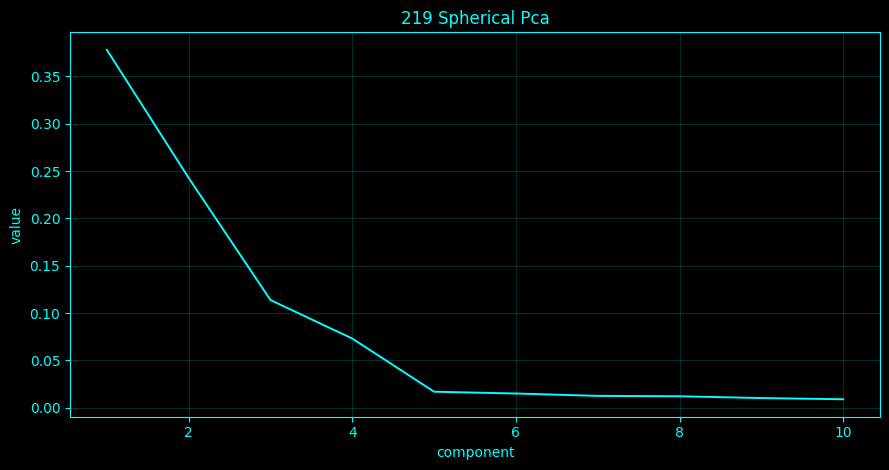

,component,explained_fraction
0,1,0.378062
1,2,0.242779
2,3,0.113790
3,4,0.073114
4,5,0.016973
5,6,0.015080
6,7,0.012575
7,8,0.012162
8,9,0.010274
9,10,0.009019


In [227]:
TV=np.stack([slogmap(SMU,x) for x in SPH]);U,s,Vt=np.linalg.svd(TV-TV.mean(0),full_matrices=False);ev=s*s/max(len(TV)-1,1);hsave('219_spherical_pca',pd.DataFrame({'component':np.arange(1,min(10,len(ev))+1),'explained_fraction':ev[:10]/(ev.sum()+EPS)}))

### Directional statistics on EEG state vectors

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Directional statistics on EEG state vectors</h3><p>The resultant length R=||mean u|| summarizes directional concentration on the sphere. R near zero indicates dispersed directions; R near one indicates strong concentration.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$R=\left\|N^{-1}\sum_i u_i\right\|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


 resultant_length  circular_variance  dimension
         0.134357           0.865643         64


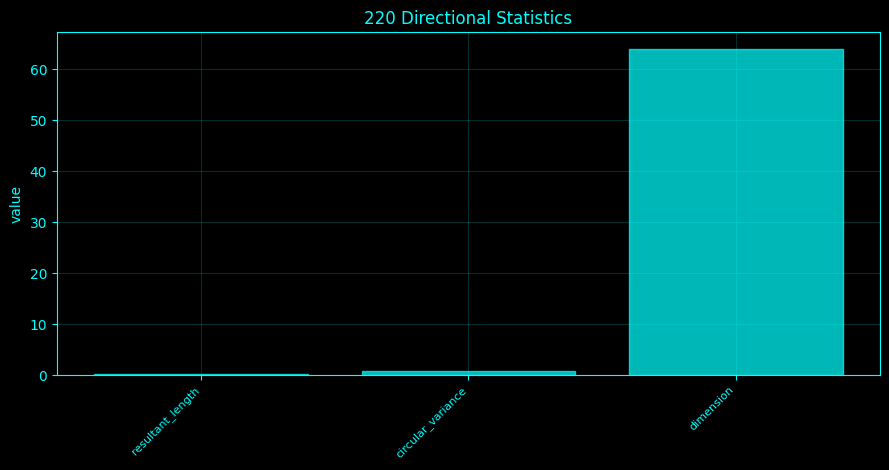

,resultant_length,circular_variance,dimension
0,0.134357,0.865643,64


In [228]:
Rbar=np.linalg.norm(SPH.mean(0));hsave('220_directional_statistics',pd.DataFrame({'resultant_length':[Rbar],'circular_variance':[1-Rbar],'dimension':[SPH.shape[1]]}))

### von Mises-Fisher geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — von Mises-Fisher geometry</h3><p>The von Mises–Fisher distribution has density proportional to exp(kappa mu dot x). Concentration kappa is estimated from resultant length using a standard high-dimensional moment approximation.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$\hat\kappa\approx R(p-R^2)/(1-R^2).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Regression fits a mathematical relationship between predictors and an outcome by choosing coefficients that minimize a loss, usually squared error. Ridge regression adds a penalty on large coefficients, which can stabilize estimates when predictors are correlated or data are limited. The coefficient of determination R² summarizes how much of the observed variance is explained by the fitted relationship within the analyzed data, but a high R² does not prove causality or guarantee good out-of-sample prediction.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 resultant_length  kappa_moment_approx  sphere_dimension
         0.134357             8.754469                63


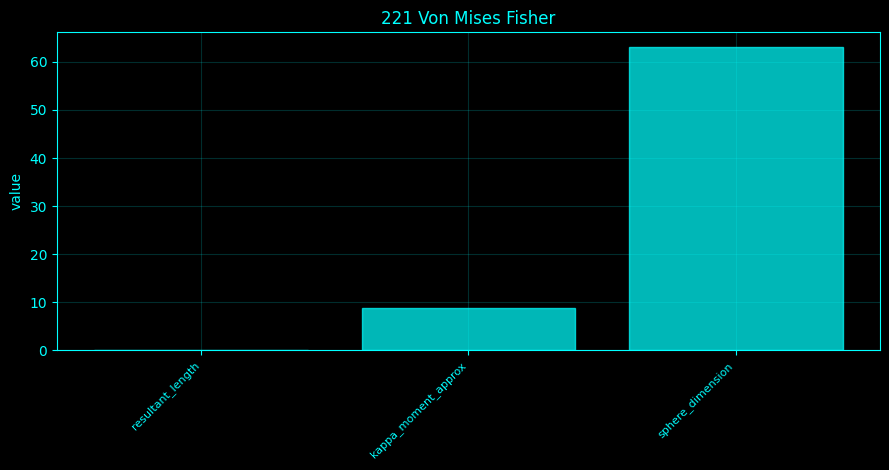

,resultant_length,kappa_moment_approx,sphere_dimension
0,0.134357,8.754469,63


In [229]:
pdim=SPH.shape[1];kap=max(0,Rbar*(pdim-Rbar*Rbar)/(1-Rbar*Rbar+EPS));hsave('221_von_mises_fisher',pd.DataFrame({'resultant_length':[Rbar],'kappa_moment_approx':[kap],'sphere_dimension':[pdim-1]}))

### Great-circle interpolation

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Great-circle interpolation</h3><p>Spherical linear interpolation (SLERP) follows the unique short great-circle geodesic when endpoints are not antipodal. Its distance from the start grows linearly with interpolation parameter.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$\gamma(t)=\frac{\sin((1-t)\theta)}{\sin\theta}x+\frac{\sin(t\theta)}{\sin\theta}y.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


   t  distance_from_start  expected  norm
0.00             0.000001  0.000000   1.0
0.05             0.031826  0.031826   1.0
0.10             0.063653  0.063653   1.0
0.15             0.095479  0.095479   1.0
0.20             0.127306  0.127306   1.0
0.25             0.159132  0.159132   1.0
0.30             0.190959  0.190959   1.0
0.35             0.222785  0.222785   1.0
0.40             0.254612  0.254612   1.0
0.45             0.286438  0.286438   1.0
0.50             0.318265  0.318265   1.0
0.55             0.350091  0.350091   1.0


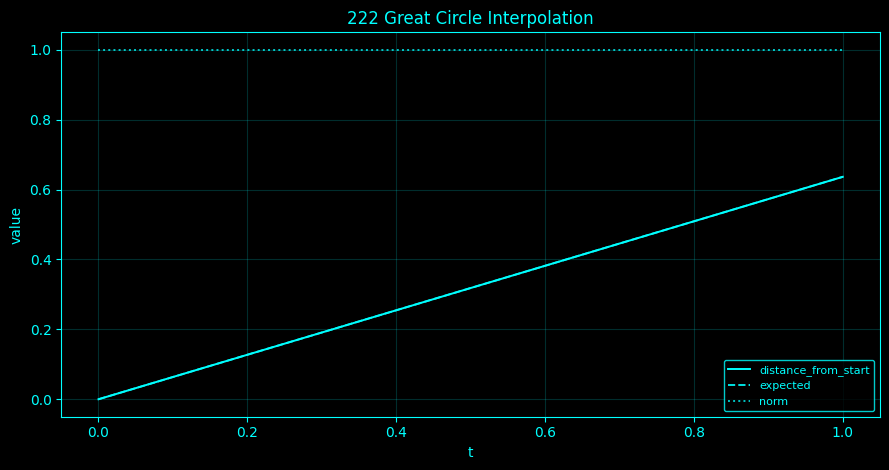

,t,distance_from_start,expected,norm
0,0.00,0.000001,0.000000,1.0
1,0.05,0.031826,0.031826,1.0
2,0.10,0.063653,0.063653,1.0
3,0.15,0.095479,0.095479,1.0
4,0.20,0.127306,0.127306,1.0
5,0.25,0.159132,0.159132,1.0
6,0.30,0.190959,0.190959,1.0
7,0.35,0.222785,0.222785,1.0
8,0.40,0.254612,0.254612,1.0
9,0.45,0.286438,0.286438,1.0


In [230]:
x,y=SPH[0],SPH[-1];th=sdist(x,y);rows=[]
for t in np.linspace(0,1,21):z=slerp(x,y,t);z/=np.linalg.norm(z)+EPS;rows.append((t,sdist(x,z),t*th,np.linalg.norm(z)))
hsave('222_great_circle_interpolation',pd.DataFrame(rows,columns=['t','distance_from_start','expected','norm']))

### Phase-vector spherical geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Phase-vector spherical geometry</h3><p>Each channel contributes a unit complex phase component; the spherical dot product equals the average cosine phase difference across channels for two time points.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$u(t)^Tu(s)=n_C^{-1}\sum_c\cos(\phi_c(t)-\phi_c(s)).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


 time_a  time_b  mean_cos_phase_difference  great_circle_distance
814.571 814.984                   0.631121               0.887799
815.810 816.223                   0.829990               0.591706
817.048 817.461                   0.797984               0.646853
818.287 818.700                   0.552334               0.985635
819.939 820.352                   0.595056               0.933461
821.178 821.590                   0.673506               0.831855
822.416 822.829                   0.785832               0.666756
823.655 824.068                   0.444367               1.110329
825.307 825.719                   0.755252               0.714757
826.545 826.958                   0.537553               1.003264
827.784 828.197                   0.724156               0.760986
829.023 829.436                   0.350706               1.212472


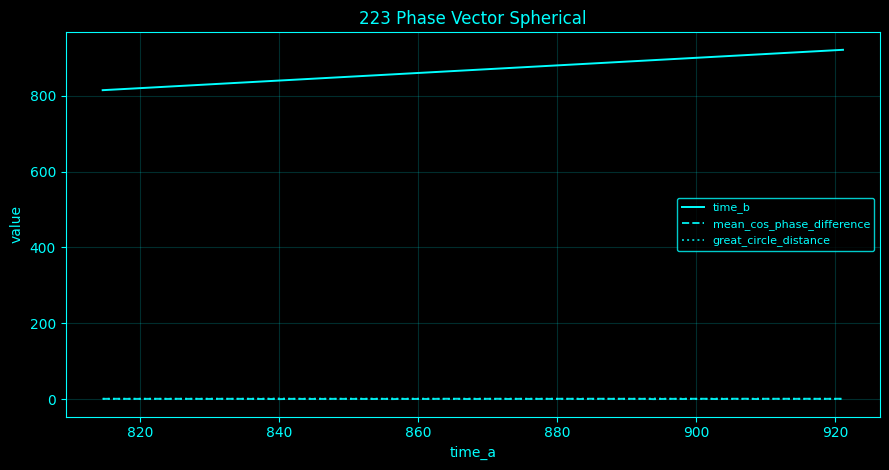

,time_a,time_b,mean_cos_phase_difference,great_circle_distance
0,814.571,814.984,0.631121,0.887799
1,815.810,816.223,0.829990,0.591706
2,817.048,817.461,0.797984,0.646853
3,818.287,818.700,0.552334,0.985635
4,819.939,820.352,0.595056,0.933461
...,...,...,...,...
75,915.320,915.733,0.858882,0.537714
76,916.972,917.385,0.827959,0.595338
77,918.211,918.624,0.503210,1.043487
78,919.449,919.862,0.900659,0.449513


In [231]:
pairs=min(80,len(SPH)-1);rows=[]
for i in np.linspace(0,len(SPH)-2,pairs,dtype=int):rows.append((ST[i],ST[i+1],float(SPH[i]@SPH[i+1]),sdist(SPH[i],SPH[i+1])))
hsave('223_phase_vector_spherical',pd.DataFrame(rows,columns=['time_a','time_b','mean_cos_phase_difference','great_circle_distance']))

### Unit-norm covariance geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Unit-norm covariance geometry</h3><p>Vectorized symmetric covariance matrices, after centering and Frobenius normalization, lie on a unit sphere in the ambient symmetric-matrix vector space. Great-circle angles then measure direction of covariance-pattern change, distinct from intrinsic SPD AIRM distance.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$q(C)=vec(C)/\|C\|_F,\quad d=\arccos(q(C)^Tq(D)).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  spherical_covariance_angle
  818.071                    0.515186
  820.571                    0.488646
  823.071                    0.090698
  825.571                    0.040200
  828.071                    0.047805
  830.571                    0.046572
  833.071                    0.040207
  835.571                    0.459663
  838.071                    0.445226
  840.571                    0.057220
  843.071                    0.050054
  845.571                    0.062891


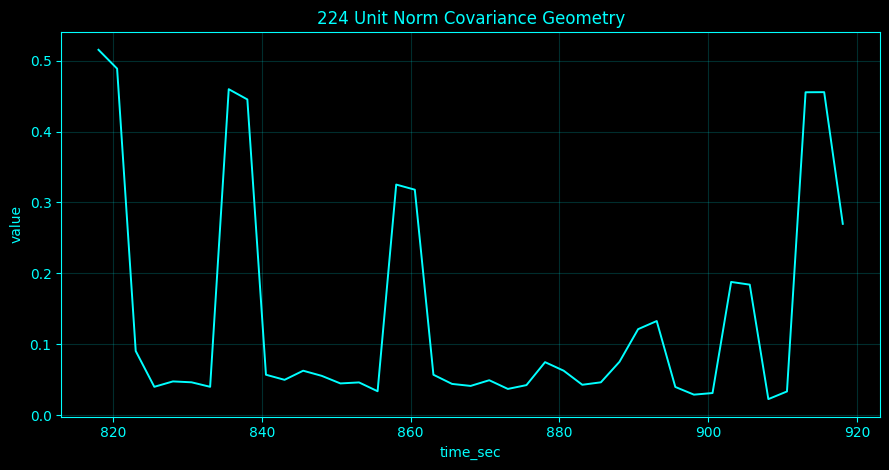

,time_sec,spherical_covariance_angle
0,818.071,0.515186
1,820.571,0.488646
2,823.071,0.090698
3,825.571,0.040200
4,828.071,0.047805
5,830.571,0.046572
6,833.071,0.040207
7,835.571,0.459663
8,838.071,0.445226
9,840.571,0.057220


In [232]:
CV=np.stack([symvec(C) for C in COV]);CV/=np.linalg.norm(CV,axis=1,keepdims=True)+EPS;d=[sdist(CV[i],CV[i+1]) for i in range(len(CV)-1)];hsave('224_unit_norm_covariance_geometry',pd.DataFrame({'time_sec':STATE_TIMES[1:],'spherical_covariance_angle':d}))

### Hyperspherical channel fingerprints

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Hyperspherical channel fingerprints</h3><p>Square-root normalized band-power compositions have unit norm and therefore lie on the positive orthant of a sphere. Channel fingerprints are their spherical distance to the normalized mean spectral direction.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts or numerical optimization budgets. The constant-curvature formulas themselves are unchanged.</p></div>

$$q_c=\sqrt{p_c},\quad d_c=\arccos(q_c^T\bar q).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


channel  spherical_bandpower_distance_to_mean
    Fp1                              0.475849
    Fpz                              0.485030
    Fp2                              0.524039
     F7                              0.072408
     F3                              0.092162
     Fz                              0.236284
     F4                              0.182035
     F8                              0.103710
    FC5                              0.070573
    FC1                              0.130592
    FC2                              0.140595
    FC6                              0.068387


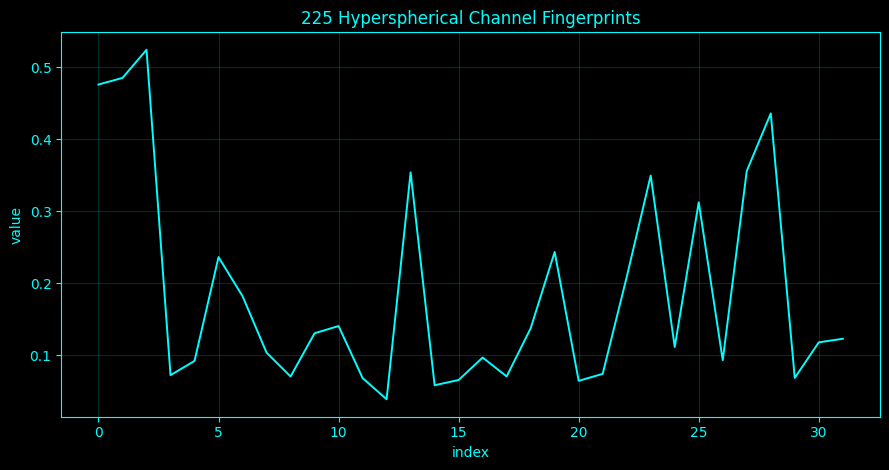

,channel,spherical_bandpower_distance_to_mean
0,Fp1,0.475849
1,Fpz,0.485030
2,Fp2,0.524039
3,F7,0.072408
4,F3,0.092162
5,Fz,0.236284
6,F4,0.182035
7,F8,0.103710
8,FC5,0.070573
9,FC1,0.130592


In [233]:
Q=np.sqrt(BP_PROB.T);Q/=np.linalg.norm(Q,axis=1,keepdims=True)+EPS;qm=Q.mean(0);qm/=np.linalg.norm(qm)+EPS;hsave('225_hyperspherical_channel_fingerprints',pd.DataFrame({'channel':eeg_channel_names,'spherical_bandpower_distance_to_mean':[sdist(q,qm) for q in Q]}))

# Geometry catalogue continuation — entries 226–250

Lie groups, Stiefel manifolds and Grassmannian subspace geometry.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Shared Lie/Stiefel/Grassmann foundation</h3><p>A moving orthonormal frame along the three-dimensional EEG state trajectory defines rotations in SO(3), and homogeneous matrices combine frame and position into SE(3) poses. Matrix logarithms map nearby transformations to Lie algebras. Window covariance eigenspaces define orthonormal frames on the Stiefel manifold and equivalence classes of subspaces on the Grassmann manifold; Grassmann distances use principal angles, which are invariant to basis rotations within a subspace.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$d_{SO(3)}(R_1,R_2)=\arccos\!\frac{\operatorname{tr}(R_1^TR_2)-1}{2},\qquad d_{Gr}(X,Y)=\|\Theta\|_2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Lie/Grassmann foundation: ultra frames 42 subspaces 42


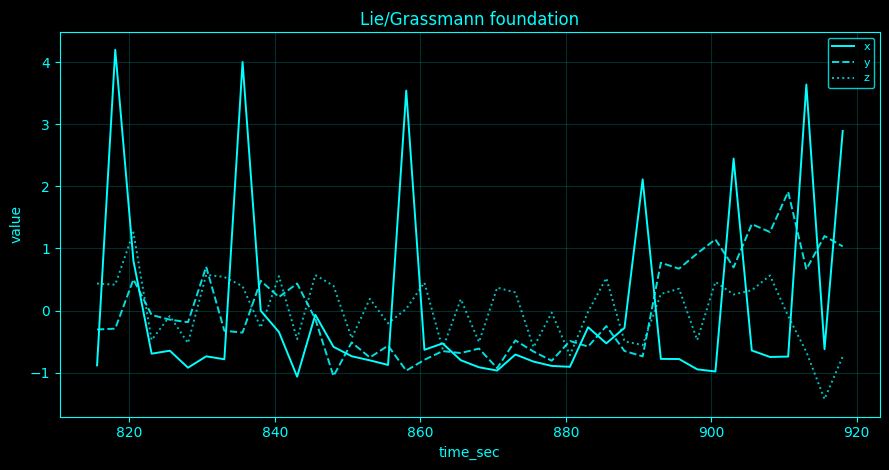

True

In [234]:
from scipy.linalg import logm,expm,polar
from scipy.spatial.transform import Rotation as Rot
LG_CFG={'full':dict(frames=180,mean=40),'balanced':dict(frames=140,mean=28),'fast':dict(frames=100,mean=18),'ultra':dict(frames=65,mean=10)}[FAST_OPTION]
LG_OUT=os.path.join(base_dir,'results','geometry_catalogue_lie_grassmann');os.makedirs(LG_OUT,exist_ok=True)
def lgdir(s):d=os.path.join(LG_OUT,s);os.makedirs(d,exist_ok=True);return d
def lgsave(s,df):df.to_csv(os.path.join(lgdir(s),f'{s}_{FAST_OPTION}.csv'),index=False);print(df.head(12).to_string(index=False));catalogue_autoplot_df(s,df);return df
def so3_dist(A,B):
 M=A.T@B;c=np.clip((np.trace(M)-1)/2,-1,1);return float(np.arccos(c))
def so3_mean(Rs):
 M=Rs[0].copy()
 for _ in range(LG_CFG['mean']):
  V=np.mean([np.real_if_close(logm(M.T@R)).astype(float) for R in Rs],axis=0);n=np.linalg.norm(V,'fro')
  if n<1e-9:break
  M=M@expm(V);U,_,Vt=np.linalg.svd(M);M=U@Vt
  if np.linalg.det(M)<0:U[:,-1]*=-1;M=U@Vt
 return M
def frame_from_va(v,a):
 T=v/(np.linalg.norm(v)+EPS);B=np.cross(v,a);nb=np.linalg.norm(B)
 if nb<EPS:
  # choose any stable normal perpendicular to T
  e=np.eye(3)[np.argmin(np.abs(T))];B=np.cross(T,e);nb=np.linalg.norm(B)
 B/=nb+EPS;N=np.cross(B,T);N/=np.linalg.norm(N)+EPS;Q=np.column_stack([T,N,B])
 if np.linalg.det(Q)<0:Q[:,-1]*=-1
 return Q
# moving frames from trajectory block
pick=np.unique(np.linspace(0,len(R)-1,min(len(R),LG_CFG['frames'])).round().astype(int));FRAMES=np.stack([frame_from_va(V[i],A[i]) for i in pick]);FT=RT[pick];RP=R[pick]
def se3_pose(Q,p):T=np.eye(4);T[:3,:3]=Q;T[:3,3]=p;return T
POSE=np.stack([se3_pose(q,p) for q,p in zip(FRAMES,RP)])
def se3_logvec(T):
 X=np.real_if_close(logm(T)).astype(float);return np.r_[X[2,1],X[0,2],X[1,0],X[:3,3]]
def principal_angles(X,Y):
 s=np.linalg.svd(X.T@Y,compute_uv=False);return np.arccos(np.clip(s,-1,1))
def grass_dist(X,Y):return float(np.linalg.norm(principal_angles(X,Y)))
def grass_geodesic(X,Y,t):
 k=X.shape[1];M=X.T@Y
 A0=(np.eye(X.shape[0])-X@X.T)@Y@np.linalg.pinv(M);U,s,Vt=np.linalg.svd(A0,full_matrices=False);th=np.arctan(s);V=Vt.T
 # tangent SVD is U diag(theta) V^T; geodesic formula
 G=X@V@np.diag(np.cos(t*th))@V.T + U[:,:k]@np.diag(np.sin(t*th))@V.T
 Q,_=np.linalg.qr(G);return Q[:,:k]
# window covariance top-3 channel subspaces
kG=3;US=[]
for C in COV:
 w,Q=np.linalg.eigh(C);US.append(Q[:,np.argsort(w)[-kG:]])
US=np.asarray(US)
# local channel-shape barycenter; avoids dependence on a prior method cell
def lg_preshape(X):
 X=X-X.mean(0);return X/(np.linalg.norm(X)+EPS)
def lg_align(A,B):
 H=B.T@A;U,_,Vt=np.linalg.svd(H);Q=U@Vt
 if np.linalg.det(Q)<0:U[:,-1]*=-1;Q=U@Vt
 return B@Q,Q
M_LG=lg_preshape(CH_SH[0]);
for _ in range(8):
 AA=np.stack([lg_align(M_LG,lg_preshape(X))[0] for X in CH_SH]);Mn=lg_preshape(AA.mean(0))
 if np.linalg.norm(Mn-M_LG)<1e-8:break
 M_LG=Mn
print('Lie/Grassmann foundation:',FAST_OPTION,'frames',len(FRAMES),'subspaces',len(US))
# Visible foundation diagnostic
catalogue_autoplot_df('lie_grassmann_foundation',pd.DataFrame({'time_sec':FT,'x':RP[:,0],'y':RP[:,1],'z':RP[:,2]}),title='Lie/Grassmann foundation')


### Lie group geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Lie group geometry</h3><p>The moving EEG trajectory frames form elements of SO(3), a noncommutative Lie group. Consecutive geodesic rotation angles summarize frame evolution independently of Euler-angle conventions.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density or iterative mean/PCA budgets; group and manifold formulas are unchanged.</p></div>

$$R_i\in SO(3),\quad R_i^TR_i=I,\ \det R_i=1.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


 time_sec  SO3_increment_angle
  818.071             0.690260
  820.571             2.635275
  823.071             0.686487
  825.571             2.715046
  828.071             2.070811
  830.571             1.285112
  833.071             1.550615
  835.571             1.153042
  838.071             2.109466
  840.571             1.218153
  843.071             2.525222
  845.571             2.525104


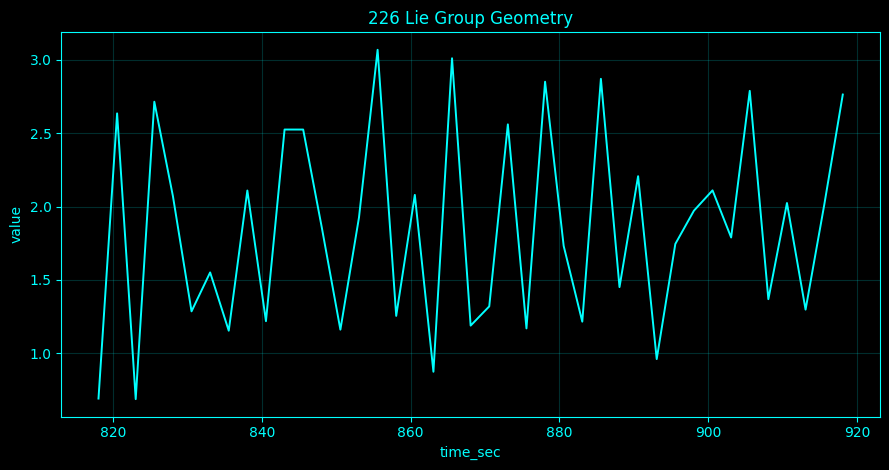

,time_sec,SO3_increment_angle
0,818.071,0.690260
1,820.571,2.635275
2,823.071,0.686487
3,825.571,2.715046
4,828.071,2.070811
5,830.571,1.285112
6,833.071,1.550615
7,835.571,1.153042
8,838.071,2.109466
9,840.571,1.218153


In [235]:
d=[so3_dist(FRAMES[i],FRAMES[i+1]) for i in range(len(FRAMES)-1)];lgsave('226_lie_group_geometry',pd.DataFrame({'time_sec':FT[1:],'SO3_increment_angle':d}))